# Bayes without Underfitting — a walkthrough

### What this notebook is

A guided tour of [arXiv:2410.16901](https://arxiv.org/abs/2410.16901), *"Bayes
without Underfitting: Fully Correlated Deep Learning Posteriors via Alternating
Projections"* (Miani, Roy & Hauberg, DTU), and of the code in this repository
that applies it to a small language model.

It builds up from scratch: every idea gets an intuition, a piece of maths, a
runnable experiment, and a picture. You need linear algebra (matrices,
eigenvalues, null spaces), basic probability (Gaussians), and enough PyTorch to
read a training loop. No Bayesian deep learning background assumed.

### Where we're going

1. **The problem** — why "being Bayesian" about a neural network often makes it
   *worse*.
2. **The idea** — some directions in weight space don't change your predictions
   at all. Put your uncertainty *there*.
3. **The algorithm** — how to project onto that set of directions without ever
   building a gigantic matrix.
4. **The LLM twist** — why the main method is impossible for a language model,
   and what replaces it.
5. **What we found** — five concrete results from implementing it, including two
   that change how you should use the method.

In [86]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.func import functional_call, jvp, vjp

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)   # tight numerics for the demos
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
print("torch", torch.__version__)

torch 2.14.0+cpu


---
## 1. The problem: Bayesian deep learning underfits

### The setup

You train a network and get weights $\theta_{\text{map}}$. ("MAP" = *maximum a
posteriori*, i.e. the best single setting of the weights.) It fits your training
data well.

Now you want **uncertainty estimates** — not just a prediction, but how confident
the model is. The standard Bayesian recipe: instead of one weight vector, use a
*distribution* over weights,

$$q(\theta) = \mathcal{N}(\theta_{\text{map}}, \Sigma),$$

then predict by averaging over samples: $\mathbb{E}_{\theta \sim q}[f(\theta, x)]$.
Where the samples agree, you're confident; where they disagree, you're not.

### The problem

In practice this **makes predictions worse**. The averaged Bayesian prediction is
often less accurate than just using $\theta_{\text{map}}$. You pay for
uncertainty with accuracy. The paper calls this *underfitting*, and its opening
sentence is blunt about it: "Bayesian deep learning tends to underfit."

Let's watch it happen.

In [87]:
# A tiny regression problem: fit sin(5x + 1) on [0, 1].
def target(x):
    return torch.sin(5 * x + 1)

N, D_IN = 60, 1
x_train = torch.rand(N, D_IN)
y_train = target(x_train) + 0.01 * torch.randn(N, 1)

model = nn.Sequential(nn.Linear(D_IN, 16), nn.Tanh(), nn.Linear(16, 16),
                      nn.Tanh(), nn.Linear(16, 1))

opt = torch.optim.Adam(model.parameters(), lr=1e-2)
for step in range(3000):
    loss = ((model(x_train) - y_train) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

print(f"trained: train MSE = {loss.item():.3e}")

# Freeze theta_map and set up a functional (pure) view of the model, so we can
# evaluate f(theta, x) for any theta without mutating the module.
names = [n for n, _ in model.named_parameters()]
theta_map = {n: p.detach().clone() for n, p in model.named_parameters()}
shapes = [theta_map[n].shape for n in names]
numels = [theta_map[n].numel() for n in names]
P = sum(numels)

def unflatten(v):
    out, i = {}, 0
    for n, sh, ne in zip(names, shapes, numels):
        out[n] = v[i:i + ne].view(sh); i += ne
    return out

def flatten(d):
    return torch.cat([d[n].reshape(-1) for n in names])

def f_model(theta, x):
    return functional_call(model, theta, (x,))

def train_mse(theta):
    return float(((f_model(theta, x_train) - y_train) ** 2).mean())

print(f"P = {P} parameters, train MSE at theta_map = {train_mse(theta_map):.3e}")

trained: train MSE = 7.179e-05
P = 321 parameters, train MSE at theta_map = 7.181e-05


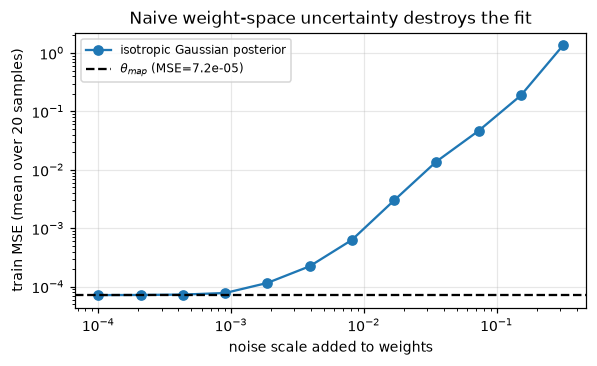

MSE at theta_map              : 7.181e-05
MSE with noise scale 1e-2     : 6.316e-04


In [88]:
# Now be "Bayesian" the naive way: add isotropic Gaussian noise to the weights.
# This is what a diagonal / mean-field posterior effectively does.
scales = np.logspace(-4, -0.5, 12)
naive_mse = []
for s in scales:
    vals = [train_mse({n: theta_map[n] + s * torch.randn_like(theta_map[n])
                       for n in names}) for _ in range(20)]
    naive_mse.append(np.mean(vals))

base = train_mse(theta_map)
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.loglog(scales, naive_mse, "o-", label="isotropic Gaussian posterior")
ax.axhline(base, color="k", ls="--", label=f"$\\theta_{{map}}$ (MSE={base:.1e})")
ax.set_xlabel("noise scale added to weights")
ax.set_ylabel("train MSE (mean over 20 samples)")
ax.set_title("Naive weight-space uncertainty destroys the fit")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"MSE at theta_map              : {base:.3e}")
print(f"MSE with noise scale 1e-2     : {naive_mse[np.argmin(abs(scales-1e-2))]:.3e}")

**That's underfitting.** Any noise scale big enough to express meaningful
uncertainty has already wrecked the training fit. The two goals seem to be in
direct conflict:

- small $\Sigma$ → good accuracy, but useless (near-zero) uncertainty
- large $\Sigma$ → real uncertainty, but bad accuracy

The paper's insight is that **this trade-off is an artefact of choosing $\Sigma$
badly**. It disappears if you're smarter about *which directions* you put the
variance in.

---
## 2. The idea: not all directions are equal

### Linearising the network

Fix $\theta_{\text{map}}$ and take a first-order Taylor expansion of the network
in its *weights* (not its inputs):

$$f(\theta, x) \;\approx\; \underbrace{f(\theta_{\text{map}}, x)}_{\text{the MAP prediction}} \;+\; J_{\theta_{\text{map}}}(x)\,(\theta - \theta_{\text{map}})$$

where $J_{\theta_{\text{map}}}(x) = \partial f / \partial \theta$ is the
**Jacobian** — for a scalar output and $P$ parameters, a $1 \times P$ row vector
saying how the prediction at $x$ responds to each weight.

Write $\delta = \theta - \theta_{\text{map}}$ for the perturbation. Then:

$$\text{prediction change at } x \;=\; J(x)\,\delta$$

### The key observation

If $J(x)\delta = 0$ for **every training point** $x$, then $\delta$ changes *no*
training prediction. Such a $\delta$ is a perturbation the training data cannot
see.

Stack all the training Jacobians into one matrix
$J = [J(x_1); J(x_2); \dots; J(x_N)] \in \mathbb{R}^{N \times P}$. The
directions we want are exactly

$$\ker(J) = \{\delta : J\delta = 0\},$$

the **null space** (or *kernel*) of $J$. Move inside $\ker(J)$ and, to first
order, the training fit is untouched — no matter how far you move.

> **Why is this space big?** $J$ is $N \times P$. A modern network has far more
> parameters than training points ($P \gg N$), so $J$ has at most rank $N$ and
> its kernel has dimension at least $P - N$. There's a *lot* of room in there.
> This is the same overparameterisation that makes deep learning work.

So the proposal (paper Eq. 4–5) is the **projected posterior**:

$$q_{\text{proj}}(\theta) = \mathcal{N}\!\left(\theta_{\text{map}},\; \alpha^{-1} U U^\top\right)$$

where the columns of $U$ are an orthonormal basis of $\ker(J)$, so $UU^\top$ is
the **orthogonal projector onto the kernel**, and $\alpha$ is a prior precision
(larger $\alpha$ = tighter posterior).

Let's verify the claim directly.

In [89]:
# Build the full Jacobian J (N x P) by one JVP per parameter direction.
# Fine here because P is small; the whole point of the paper is avoiding this.
def full_jacobian():
    rows = []
    for k in range(P):
        e = torch.zeros(P); e[k] = 1.0
        _, jv = jvp(lambda th: f_model(th, x_train).squeeze(-1), (theta_map,), (unflatten(e),))
        rows.append(jv)
    return torch.stack(rows, dim=1)      # (N, P)

J = full_jacobian()
U_, sv, Vh = torch.linalg.svd(J, full_matrices=False)
rank = int((sv > 1e-10 * sv.max()).sum())
V_row = Vh[:rank]                        # orthonormal basis of the ROW space of J
kernel_proj = torch.eye(P) - V_row.T @ V_row   # = U U^T, the kernel projector

print(f"J is {tuple(J.shape)},  rank(J) = {rank},  dim ker(J) = {P - rank}")
print(f"projector check: ||Pk^2 - Pk|| = {(kernel_proj @ kernel_proj - kernel_proj).norm():.2e}"
      "   (a projector satisfies P^2 = P)")

J is (60, 321),  rank(J) = 27,  dim ker(J) = 294
projector check: ||Pk^2 - Pk|| = 7.68e-15   (a projector satisfies P^2 = P)


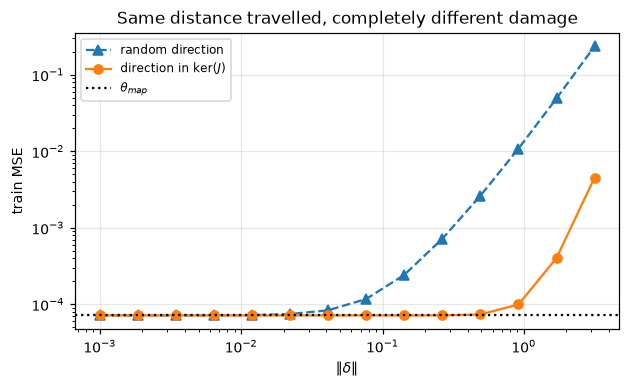

at ||delta|| = 0.92:
   random direction : MSE 1.087e-02   (   151.3x worse)
   kernel direction : MSE 9.976e-05   (     1.4x worse)


In [90]:
# Compare perturbations INSIDE the kernel vs random ones, at matched size.
g = torch.Generator().manual_seed(3)
eps = torch.randn(P, generator=g)
d_kernel = kernel_proj @ eps
d_kernel = d_kernel / d_kernel.norm()
d_random = eps / eps.norm()

scales = np.logspace(-3, 0.5, 14)
mse_kernel, mse_random = [], []
for s in scales:
    mse_kernel.append(train_mse({n: theta_map[n] + v for n, v in unflatten(d_kernel * s).items()}))
    mse_random.append(train_mse({n: theta_map[n] + v for n, v in unflatten(d_random * s).items()}))

fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.loglog(scales, mse_random, "^--", label="random direction")
ax.loglog(scales, mse_kernel, "o-", label=r"direction in $\ker(J)$")
ax.axhline(base, color="k", ls=":", label=r"$\theta_{map}$")
ax.set_xlabel(r"$\|\delta\|$"); ax.set_ylabel("train MSE")
ax.set_title("Same distance travelled, completely different damage")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

i = np.argmin(abs(scales - 1.0))
print(f"at ||delta|| = {scales[i]:.2f}:")
print(f"   random direction : MSE {mse_random[i]:.3e}   ({mse_random[i]/base:8.1f}x worse)")
print(f"   kernel direction : MSE {mse_kernel[i]:.3e}   ({mse_kernel[i]/base:8.1f}x worse)")

### First, let's actually look at $J$

We keep talking about the Jacobian as if it were an abstract object. It's a
concrete $N \times P$ matrix and we can just print it. Three views, each of which
will matter later.

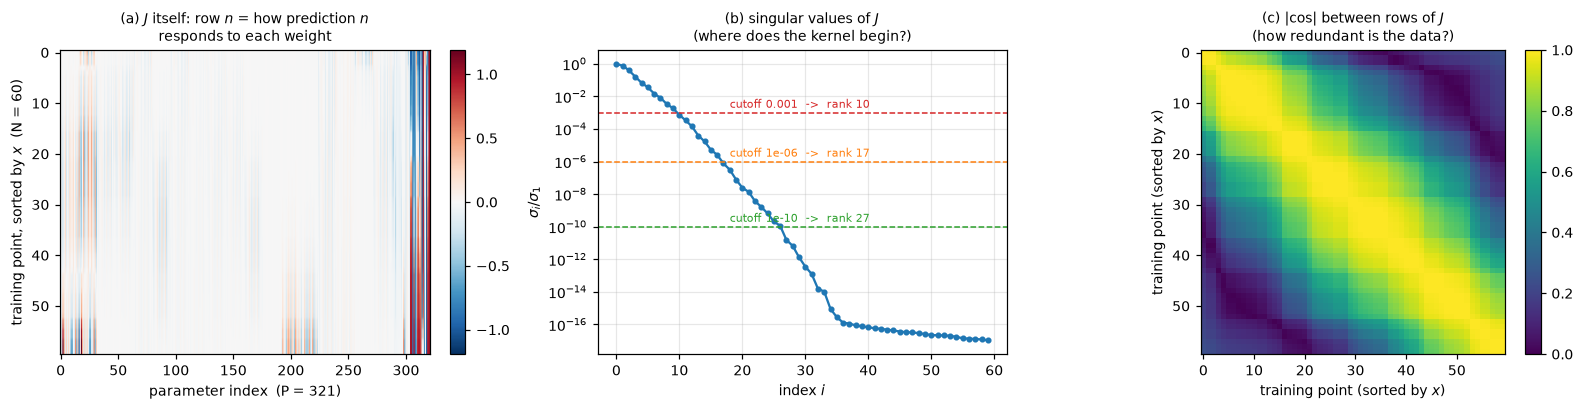

J is (60, 321)  ->  at most rank 60
off-diagonal |cos| between Jacobian rows: median 0.6331, 10th pct 0.0946

sigma_1 / sigma_N = 9.372e+16   (condition number of J)


In [91]:
# Sort the rows by x. The training points arrive in random order, and without
# sorting the structure below is invisible -- an easy way to fool yourself.
order = torch.argsort(x_train.squeeze())
Jnp = J[order].numpy()
fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.8))

# --- (a) the matrix itself ---
lim = np.abs(Jnp).max()
im = ax[0].imshow(Jnp, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
ax[0].set_xlabel(f"parameter index  (P = {P})")
ax[0].set_ylabel(f"training point, sorted by $x$  (N = {N})")
ax[0].set_title("(a) $J$ itself: row $n$ = how prediction $n$\nresponds to each weight",
                fontsize=9)
ax[0].grid(False)
fig.colorbar(im, ax=ax[0], fraction=0.046)

# --- (b) singular values: "the rank" is a choice, not a fact ---
sv = torch.linalg.svdvals(J).numpy()
ax[1].semilogy(sv / sv[0], "o-", ms=3)
for rt, c in [(1e-3, "tab:red"), (1e-6, "tab:orange"), (1e-10, "tab:green")]:
    r = int((sv > rt * sv[0]).sum())
    ax[1].axhline(rt, color=c, ls="--", lw=1)
    ax[1].annotate(f"cutoff {rt:g}  ->  rank {r}", (len(sv) * 0.30, rt * 2.0),
                   fontsize=7, color=c)
ax[1].set_xlabel("index $i$")
ax[1].set_ylabel(r"$\sigma_i / \sigma_1$")
ax[1].set_title("(b) singular values of $J$\n(where does the kernel begin?)", fontsize=9)

# --- (c) do different data points say different things? ---
Js = J[order]
Jn = Js / Js.norm(dim=1, keepdim=True)
Cm = (Jn @ Jn.T).numpy()
im = ax[2].imshow(np.abs(Cm), cmap="viridis", vmin=0, vmax=1)
ax[2].set_xlabel("training point (sorted by $x$)")
ax[2].set_ylabel("training point (sorted by $x$)")
ax[2].set_title("(c) $|\\cos|$ between rows of $J$\n(how redundant is the data?)",
                fontsize=9)
ax[2].grid(False)
fig.colorbar(im, ax=ax[2], fraction=0.046)

plt.tight_layout(); plt.show()

off = np.abs(Cm)[~np.eye(N, dtype=bool)]
print(f"J is {tuple(J.shape)}  ->  at most rank {min(J.shape)}")
print(f"off-diagonal |cos| between Jacobian rows: "
      f"median {np.median(off):.4f}, 10th pct {np.percentile(off, 10):.4f}")
print(f"\nsigma_1 / sigma_N = {sv[0] / sv[-1]:.3e}   (condition number of J)")

Three lessons, and each one comes back later.

**(a) The matrix is smooth and banded, not random.** Each row is one training
point's sensitivity vector. Rows for nearby $x$ look alike, because the network is
a continuous function — nearby inputs excite nearly the same weights.

**(b) "The rank of $J$" is not a well-defined number.** The singular values decay
smoothly across many orders of magnitude, so where the kernel starts depends on
the cutoff you pick: a threshold of $10^{-3}$ gives one rank, $10^{-10}$ gives a
much larger one. This is not pedantry — it means *"the kernel" is a modelling
choice*, and if two parts of your code disagree about the tolerance they are
working with different subspaces. (We hit exactly this bug while building this
notebook.)

**(c) The data is locally redundant, and you can see the band.** Rows for nearby
$x$ have $|\cos|$ close to 1 — those training points are telling us almost the
*same* thing about which weights matter — while far-apart points are nearly
orthogonal. The median off-diagonal $|\cos|$ is about $0.63$, which is enormous
for vectors in a 321-dimensional space (two random directions there would give
$pprox 0.06$). That redundancy is why the effective rank sits far below $N$, and
it is the seed of the convergence failure we diagnose in §6.1. Hold on to this
panel — we will come back to it.

**This is the entire paper in one plot.** Both perturbations have identical
length. The random one blows the training loss up by orders of magnitude; the
kernel one barely moves it.

That is the paper's Lemma 3.1: the projected posterior is *supported on functions
that agree with $\theta_{\text{map}}$ on the training data*, so it **cannot
underfit**, by construction.

The kernel direction isn't perfectly flat, and it shouldn't be — we linearised.
The residual damage is $O(\|\delta\|^2)$: second-order curvature the linear
approximation ignores. Notice the kernel curve's slope is about twice the random
curve's on the log-log plot, exactly as a quadratic-vs-linear comparison should be.

### And now: what does the kernel actually *look like*?

$\ker(J)$ is a 294-dimensional subspace of a 321-dimensional space. You cannot
draw that. But you don't need to — you can watch what it *does*. A direction in
the kernel is defined by its effect on the function, so let's plot the function.

Below: eight perturbations drawn from the kernel, and eight isotropic ones, all at
**exactly the same** $\|\delta\|$. Also the eigenvalues of the projector $UU^\top$,
which are the cleanest possible summary of "which directions survive".

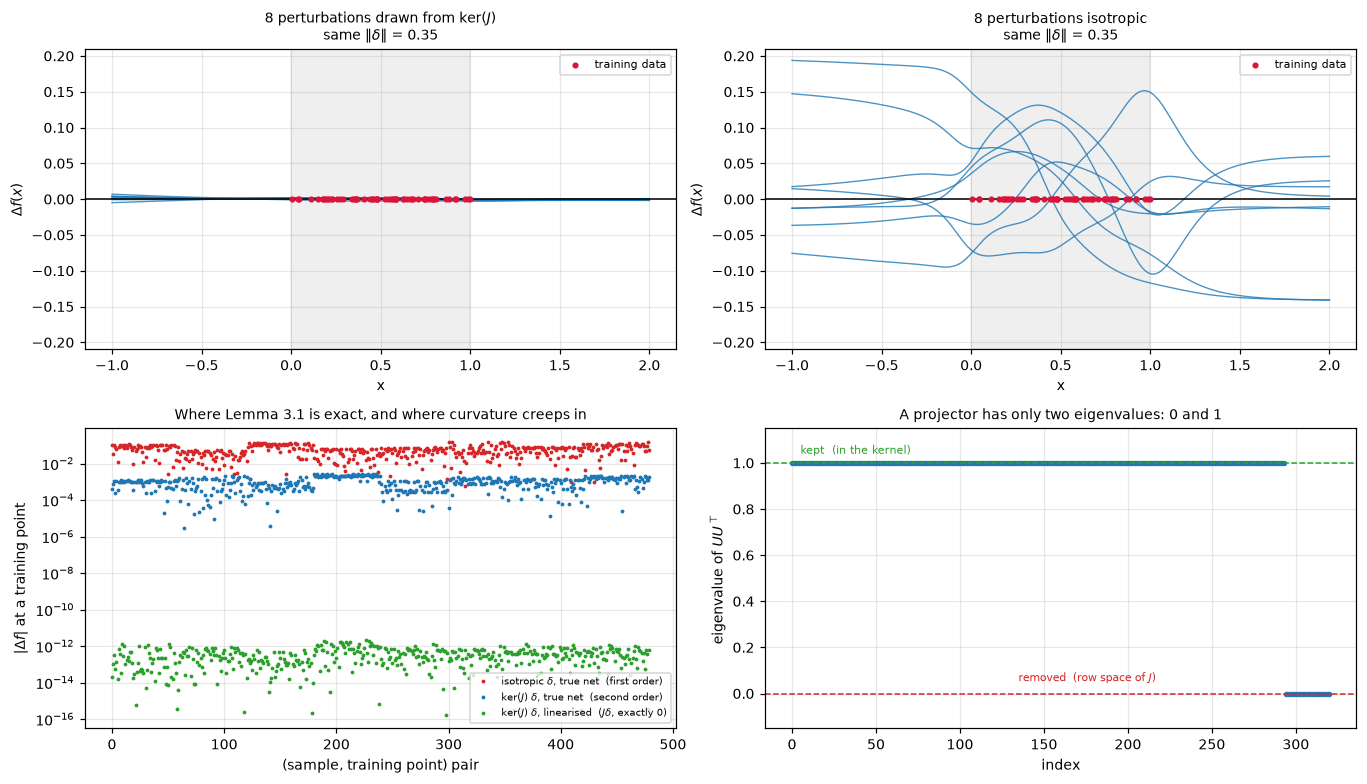

projector eigenvalues: 294 ones, 27 zeros   (trace = 294.0000 = the kernel dimension)

max |change in f| AT the training points, ||delta|| = 0.35
   isotropic, true network   : 1.516e-01   <- first order
   ker(J),    true network   : 2.667e-03   <- second order only
   ker(J),    LINEARISED     : 2.189e-12   <- exactly zero

   ratio isotropic / kernel  : 57x

max |change in f| OUTSIDE [0, 1]
   kernel directions   : 7.010e-03
   isotropic directions: 1.938e-01


In [92]:
x_fine = torch.linspace(-1.0, 2.0, 200).reshape(-1, 1)
f0_fine = f_model(theta_map, x_fine).squeeze(-1).detach()
f0_train = f_model(theta_map, x_train).squeeze(-1).detach()
STEP = 0.35                                  # comfortably inside the linear regime

# Plot the CHANGE in the function, not the function. A single random direction in
# a 294-dimensional kernel is nearly orthogonal to any fixed vector, so it moves
# f by ~0.01 -- invisible if you overplot two copies of a curve of range 2.
g2 = torch.Generator().manual_seed(21)
ker_fine, rnd_fine, ker_tr, rnd_tr, ker_lin = [], [], [], [], []
for _ in range(8):
    e = torch.randn(P, generator=g2)
    d_ker = kernel_proj @ e
    d_ker = d_ker / d_ker.norm() * STEP
    d_rnd = e / e.norm() * STEP
    for d, acc_fine, acc_tr in [(d_ker, ker_fine, ker_tr), (d_rnd, rnd_fine, rnd_tr)]:
        th = {n: theta_map[n] + v for n, v in unflatten(d).items()}
        acc_fine.append((f_model(th, x_fine).squeeze(-1).detach() - f0_fine).numpy())
        acc_tr.append((f_model(th, x_train).squeeze(-1).detach() - f0_train).abs().numpy())
    # the LINEARISED change, J delta, which is what the lemma actually bounds
    ker_lin.append((J @ d_ker).abs().numpy())

fig, axs = plt.subplots(2, 2, figsize=(12.5, 7.2))
lim = max(np.abs(np.array(ker_fine)).max(), np.abs(np.array(rnd_fine)).max()) * 1.08

for ax, curves, ttl in [(axs[0, 0], ker_fine, r"drawn from $\ker(J)$"),
                        (axs[0, 1], rnd_fine, "isotropic")]:
    for c in curves:
        ax.plot(x_fine, c, lw=0.9, alpha=0.8, color="tab:blue")
    ax.axhline(0, color="k", lw=1.0)
    ax.axvspan(0, 1, color="grey", alpha=0.12)
    ax.scatter(x_train, np.zeros(N), s=9, c="crimson", zorder=5, label="training data")
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("x"); ax.set_ylabel(r"$\Delta f(x)$")
    ax.set_title(f"8 perturbations {ttl}\nsame $\\|\\delta\\|$ = {STEP}", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

# how big is the change AT the training points?
ax = axs[1, 0]
ax.semilogy(np.concatenate(rnd_tr) + 1e-20, ".", ms=3, color="tab:red",
            label=r"isotropic $\delta$, true net  (first order)")
ax.semilogy(np.concatenate(ker_tr) + 1e-20, ".", ms=3, color="tab:blue",
            label=r"$\ker(J)$ $\delta$, true net  (second order)")
ax.semilogy(np.concatenate(ker_lin) + 1e-20, ".", ms=3, color="tab:green",
            label=r"$\ker(J)$ $\delta$, linearised  ($J\delta$, exactly 0)")
ax.set_xlabel("(sample, training point) pair")
ax.set_ylabel(r"$|\Delta f|$ at a training point")
ax.set_title("Where Lemma 3.1 is exact, and where curvature creeps in",
             fontsize=9)
ax.legend(fontsize=6.5, loc="lower right")

# the projector's spectrum
ax = axs[1, 1]
ev = torch.linalg.eigvalsh(kernel_proj).numpy()
ax.plot(np.sort(ev)[::-1], "o", ms=2.5)
ax.set_xlabel("index"); ax.set_ylabel(r"eigenvalue of $UU^\top$")
ax.set_ylim(-0.15, 1.15)
ax.axhline(1, color="tab:green", ls="--", lw=1)
ax.axhline(0, color="tab:red", ls="--", lw=1)
ax.annotate("kept  (in the kernel)", (5, 1.04), fontsize=7, color="tab:green")
ax.annotate("removed  (row space of $J$)", (len(ev) * 0.42, 0.05), fontsize=7,
            color="tab:red")
ax.set_title("A projector has only two eigenvalues: 0 and 1", fontsize=9)

plt.tight_layout(); plt.show()

n_one = int((ev > 0.5).sum())
print(f"projector eigenvalues: {n_one} ones, {len(ev) - n_one} zeros"
      f"   (trace = {ev.sum():.4f} = the kernel dimension)")
print(f"\nmax |change in f| AT the training points, ||delta|| = {STEP}")
print(f"   isotropic, true network   : {np.concatenate(rnd_tr).max():.3e}   <- first order")
print(f"   ker(J),    true network   : {np.concatenate(ker_tr).max():.3e}   <- second order only")
print(f"   ker(J),    LINEARISED     : {np.concatenate(ker_lin).max():.3e}   <- exactly zero")
print(f"\n   ratio isotropic / kernel  : "
      f"{np.concatenate(rnd_tr).max() / np.concatenate(ker_tr).max():,.0f}x")
print(f"\nmax |change in f| OUTSIDE [0, 1]")
outside = ((x_fine.squeeze() < 0) | (x_fine.squeeze() > 1)).numpy()
print(f"   kernel directions   : {np.abs(np.array(ker_fine))[:, outside].max():.3e}")
print(f"   isotropic directions: {np.abs(np.array(rnd_fine))[:, outside].max():.3e}")

Compare the top two panels. They share a $y$-axis and the perturbations have
identical length.

The **isotropic** perturbations (top right) move the function everywhere,
including right through the training data. That is underfitting, mechanically: the
model has stopped fitting its own training set, and averaging those curves gives
you something worse than $\theta_{map}$.

The **kernel** perturbations (top left) are pinned to zero across $[0,1]$ and only
lift away outside it. Note that they move the function much *less* even off-data —
that is not a failure, it is high-dimensional geometry: a single random direction
in a 294-dimensional subspace is nearly orthogonal to any particular vector, so
one sample moves $f$ only a little. The *variance over many samples* is what
Lemma 3.2 talks about, and the bathtub plot below measures it properly.

The bottom-left panel is the careful version of the claim, and it's worth being
precise about what the lemma does and does not promise.

- **Green**: the *linearised* change $J\delta$ at each training point, for kernel
  directions. This is machine zero. Lemma 3.1 is an exact statement, and this is
  it — no approximation anywhere.
- **Blue**: the change in the *actual network* $f(\theta_{map} + \delta)$ for the
  same kernel directions. Around $10^{-3}$, not zero. The first-order term
  vanished by construction, so what's left is pure curvature: the
  $O(\|\delta\|^2)$ residual the Taylor expansion discarded.
- **Red**: isotropic directions on the actual network, around $10^{-1}$. Here the
  first-order term is *not* zero and dominates everything.

So the honest summary is: the projection kills the first-order term **exactly**,
and the leftover damage is second order. That is a weaker claim than "the loss
never changes" — and it is precisely the claim Lemma 4.3 makes for the loss
version. It's also why §6.2 has to be read on log-log axes: the whole content of
the lemma is a change of *slope* from 1 to 2, not a change to zero.

The bottom-right panel is the paper's numerical-stability argument. A projector's
eigenvalues are only ever $0$ or $1$ — nothing in between — so $UU^\top$ is
perfectly conditioned, unlike the GGN whose condition number routinely exceeds
$10^6$. And the **trace equals the number of ones**, i.e. the kernel dimension:
that identity is exactly what makes Hutchinson's estimator work in §6.3.

### But wait — is the uncertainty then useless?

If samples don't change training predictions, do they change *anything*? Yes.
Lemma 3.2 says the predictive variance at a **test** point is strictly positive,
under a mild rank condition. The kernel is defined by the training points only,
so a new point generally has a Jacobian row that pokes outside their span — and
it *does* see the perturbation.

Rather than sample, we can compute the linearised predictive variance in closed
form, which is both exact and more revealing about where it comes from.

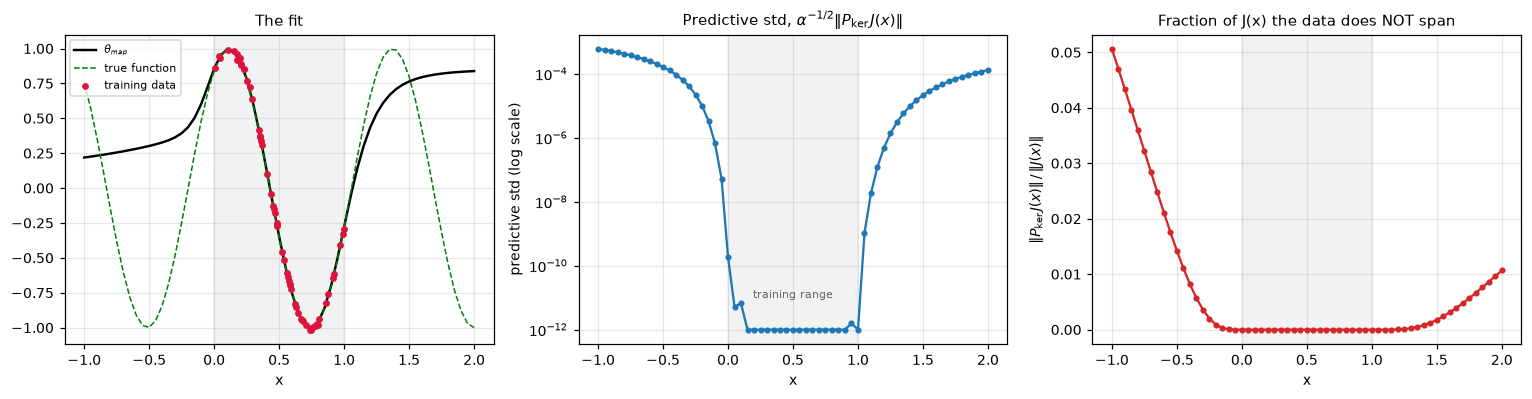

mean predictive std inside  [0,1] : 9.745e-12
mean predictive std outside [0,1] : 1.351e-04
ratio                             : 13,860,512x


In [93]:
# For the linearised model, the predictive variance has a closed form:
#     f_lin(theta, x) = f(theta_map, x) + J(x) delta,   delta ~ N(0, alpha^-1 Pk)
#  => Var f_lin(x) = alpha^-1 * || Pk J(x)^T ||^2
# No sampling needed, so no Monte-Carlo noise -- and it shows exactly WHERE the
# variance comes from: the part of J(x) that the training data does not span.
def jac_at(xs):
    rows = []
    for k in range(P):
        e = torch.zeros(P); e[k] = 1.0
        _, jv = jvp(lambda th: f_model(th, xs).squeeze(-1), (theta_map,), (unflatten(e),))
        rows.append(jv)
    return torch.stack(rows, dim=1)

x_grid = torch.linspace(-1.0, 2.0, 61).reshape(-1, 1)   # data lives in [0, 1]
alpha = 1e5

resid_norm, jac_norm = [], []
for xg in x_grid:
    Jx = jac_at(xg.reshape(1, 1))[0]
    resid_norm.append(float((kernel_proj @ Jx).norm()))   # the part NOT spanned
    jac_norm.append(float(Jx.norm()))
resid_norm = np.array(resid_norm); jac_norm = np.array(jac_norm)
pred_std = resid_norm / alpha ** 0.5

inside = ((x_grid.squeeze() >= 0) & (x_grid.squeeze() <= 1)).numpy()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.7))

ax[0].plot(x_grid, f_model(theta_map, x_grid).detach(), "k-", lw=1.6, label=r"$\theta_{map}$")
ax[0].plot(x_grid, target(x_grid), "g--", lw=1, label="true function")
ax[0].scatter(x_train, y_train, s=12, c="crimson", zorder=5, label="training data")
ax[0].axvspan(0, 1, color="grey", alpha=0.10)
ax[0].set_xlabel("x"); ax[0].legend(fontsize=7); ax[0].set_title("The fit", fontsize=10)

ax[1].semilogy(x_grid, np.maximum(pred_std, 1e-12), "o-", ms=3, color="tab:blue")
ax[1].axvspan(0, 1, color="grey", alpha=0.10)
ax[1].set_xlabel("x"); ax[1].set_ylabel(r"predictive std (log scale)")
ax[1].set_title(r"Predictive std, $\alpha^{-1/2}\|P_{\ker}J(x)\|$", fontsize=10)
ax[1].annotate("training range", xy=(0.5, pred_std[inside].mean()), fontsize=7,
               ha="center", color="dimgrey")

ax[2].plot(x_grid, resid_norm / jac_norm, "o-", ms=3, color="tab:red")
ax[2].axvspan(0, 1, color="grey", alpha=0.10)
ax[2].set_xlabel("x"); ax[2].set_ylabel(r"$\|P_{\ker}J(x)\| \, / \, \|J(x)\|$")
ax[2].set_title("Fraction of J(x) the data does NOT span", fontsize=10)

plt.tight_layout(); plt.show()

print(f"mean predictive std inside  [0,1] : {pred_std[inside].mean():.3e}")
print(f"mean predictive std outside [0,1] : {pred_std[~inside].mean():.3e}")
print(f"ratio                             : "
      f"{pred_std[~inside].mean() / pred_std[inside].mean():,.0f}x")

(The flat floor at $10^{-12}$ in the middle panel is the `np.maximum` clamp — the
true value there is numerically zero, and a log axis cannot show zero.)

Note the **log scale** on the middle panel — this is why a naive $\pm 2\sigma$
band looks like nothing at all. Inside the training range the predictive standard
deviation is $\sim\!10^{-8}$: numerically zero, exactly as Lemma 3.1 demands.
Outside it rises to $\sim\!10^{-4}$. That is a ratio of tens of thousands, but
*both numbers are tiny in absolute terms*, so if you plot a confidence band on the
same axes as a function of range $\approx 2$, you see a hairline either way. The
effect is real and enormous; it's just multiplicative, so you have to plot it
logarithmically to see it.

The right-hand panel shows the mechanism, and it is Lemma 3.2 made visible. Inside
the data, $J(x)$ lies almost entirely *within* the span of the training Jacobians,
so the kernel projector annihilates it and the variance vanishes. Move away from
the data and a growing fraction of $J(x)$ sticks out of that span — about 4% at
$x = 2$ and 15% at $x = -1$ — and that surviving fraction *is* the uncertainty.

**Confident where you have data, uncertain where you don't**, derived rather than
tuned. Note also the asymmetry: the model is more uncertain to the left of the
data than the right, because the two directions leave the training span at
different rates. Nothing in the method imposed that; it fell out of the geometry.

---
## 3. The algorithm: projecting without building the matrix

We now need $UU^\top$, the projector onto $\ker(J)$. Above we got it by taking an
SVD of the explicit $J$ — impossible at scale, because $J$ is $N \times P$ with
$P$ in the millions.

### Standard formula, and why it fails

For any matrix $M \in \mathbb{R}^{R \times P}$, the projector onto its row space is

$$\mathcal{P}(M^\top M) = M^\top (M M^\top)^{-1} M,$$

so the projector onto its kernel is $I - \mathcal{P}(M^\top M)$. In our case
$M = J H^{1/2}$ (with $H$ the loss Hessian w.r.t. outputs), giving $M M^\top$ of
size $NO \times NO$: number of training points times output dimension, **squared**.
For any real dataset that inverse is out of reach.

### Trick 1: kernels intersect

Chop the data into $B$ batches, so $M$ splits into row-blocks
$M_1, \dots, M_B$ and $M^\top M = \sum_b M_b^\top M_b$. Because each
$M_b^\top M_b$ is positive semi-definite, a vector is killed by the sum only if
it's killed by every term (paper Eq. 11):

$$\ker\Big(\sum_b M_b^\top M_b\Big) = \bigcap_b \ker\big(M_b^\top M_b\big)$$

Each per-batch projector needs only an $SO \times SO$ inverse ($S$ = batch size).
Cheap. But we want the projector onto the **intersection**, and the product of
projectors is not the projector onto the intersection.

### Trick 2: von Neumann's alternating projections

It is, however, the *limit* of repeated products (Lemma 4.1):

$$I - \mathcal{P}(M^\top M) \;=\; \lim_{t \to \infty} \left( \prod_b \big(I - \mathcal{P}(M_b^\top M_b)\big) \right)^{t}$$

Sweep through the batches, projecting onto each batch's kernel in turn, and repeat.
You spiral into the intersection. Convergence is linear with rate

$$c = \prod_{b} \cos^2(\theta_b),$$

where $\theta_b$ is the smallest angle between subspace $b$ and the others.
**Remember that rate — it is the source of our biggest practical finding.**

Let's see it in 3D, where each batch contributes one plane and the intersection
is a line.

### Aside: what does it mean for two *subspaces* to have an angle?

That rate formula contains $\cos^2(\theta_b)$, so we should be precise about what
$\theta_b$ is. For two **lines** through the origin it's the ordinary angle you'd
measure with a protractor. For higher-dimensional subspaces there isn't a single
angle — there's a whole list, the **principal angles**.

The recipe: let $Q_1$ and $Q_2$ hold orthonormal bases of the two subspaces as
columns, form $Q_1^\top Q_2$, and take its singular values
$\sigma_1 \ge \sigma_2 \ge \dots$. Then

$$\sigma_i = \cos\theta_i .$$

The construction is greedy. $\theta_1$ is the *smallest* angle achievable between
any unit vector in the first subspace and any unit vector in the second;
$\theta_2$ is the smallest angle among directions orthogonal to that first pair,
and so on down.

Two extremes are worth memorising:

| | meaning |
|---|---|
| $\theta_1 = 0^\circ$ (i.e. $\cos\theta_1 = 1$) | the subspaces **share a direction exactly** — some vector lies in both |
| all $\theta_i = 90^\circ$ (i.e. all $\cos\theta_i = 0$) | the subspaces are **orthogonal** — every direction in one is perpendicular to every direction in the other |

So $\cos\theta_1$ answers "how much do these two subspaces overlap?": 1 means they
touch, 0 means they share no direction at all.

**Why this controls alternating projections.** Projecting onto $A$ then onto $B$
moves you toward $A \cap B$, and how much you gain per step depends on how
differently the two subspaces see the world:

- **Nearly orthogonal** ($\cos\theta_1 \approx 0$): projecting onto $B$ removes a
  component that projecting onto $A$ left untouched. Every step is real progress,
  and you converge almost immediately.
- **Nearly identical** ($\cos\theta_1 \approx 1$): projecting onto $B$ removes
  almost exactly what projecting onto $A$ already removed. You are redoing the
  same work, shuffling around inside a shared subspace, and the error shrinks by
  only $\cos^2\theta_1 \approx 1$ per sweep — that is, barely at all.

Below: the two extremes with lines in the plane, then a higher-dimensional example
where we *build in* a known overlap and read it back off the principal angles.

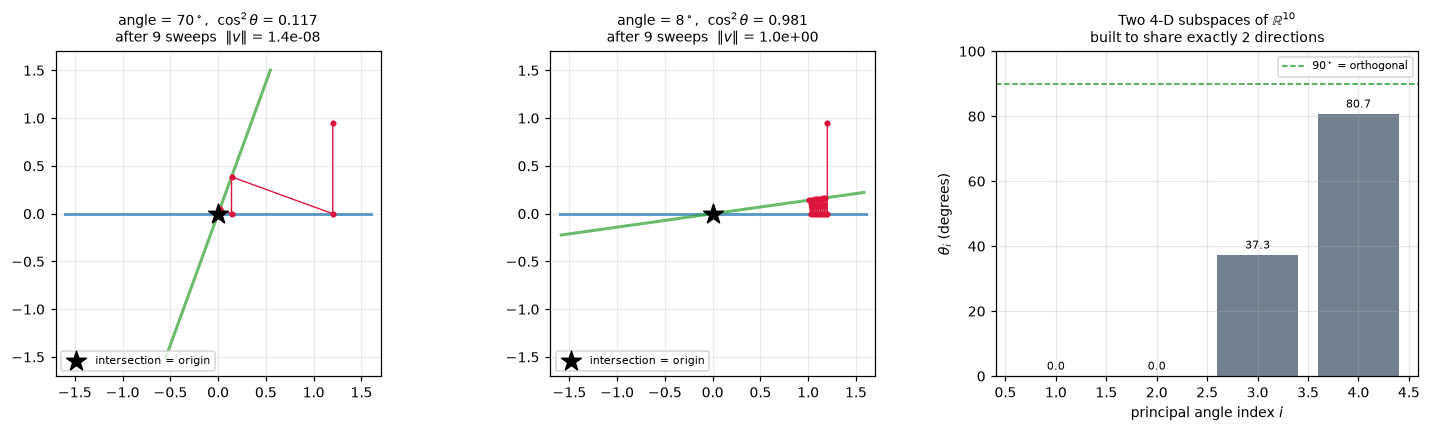

cos(theta_i) = 1.0000  1.0000  0.7960  0.1618
theta_i      = 0.00  0.00  37.25  80.69 degrees

The first two angles are 0 degrees (cos = 1) -- exactly the two directions
we planted in both subspaces. The remaining two are large, reflecting the
independently drawn directions. Principal angles recover the overlap exactly.


In [94]:
def project_onto_line(v, d):
    d = d / np.linalg.norm(d)
    return np.dot(v, d) * d

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

# --- panels 1-2: wide vs narrow angle between two lines in R^2 ---
for ax, ang_deg in zip(axes[:2], [70, 8]):
    a = np.radians(ang_deg)
    d1, d2 = np.array([1.0, 0.0]), np.array([np.cos(a), np.sin(a)])
    for d, c in [(d1, "tab:blue"), (d2, "tab:green")]:
        L = np.stack([-1.6 * d, 1.6 * d])
        ax.plot(L[:, 0], L[:, 1], color=c, lw=2, alpha=0.7)
    v = np.array([1.2, 0.95])
    pts = [v.copy()]
    for _ in range(9):
        v = project_onto_line(v, d1); pts.append(v.copy())
        v = project_onto_line(v, d2); pts.append(v.copy())
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], "o-", ms=3, lw=0.9, color="crimson")
    ax.scatter([0], [0], marker="*", s=180, c="k", zorder=5,
               label="intersection = origin")
    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.set_title(f"angle = {ang_deg}$^\\circ$,  $\\cos^2\\theta$ = "
                 f"{np.cos(a) ** 2:.3f}\nafter 9 sweeps  "
                 f"$\\|v\\|$ = {np.linalg.norm(pts[-1]):.1e}", fontsize=9)
    ax.legend(fontsize=7, loc="lower left")

# --- panel 3: two 4-D subspaces of R^10 sharing exactly 2 directions ---
gen = torch.Generator().manual_seed(0)
shared = torch.linalg.qr(torch.randn(10, 2, generator=gen))[0]     # 2 common dirs
A = torch.linalg.qr(torch.cat([shared, torch.randn(10, 2, generator=gen)], 1))[0]
B = torch.linalg.qr(torch.cat([shared, torch.randn(10, 2, generator=gen)], 1))[0]

cosines = torch.linalg.svdvals(A.T @ B).clamp(max=1.0).numpy()
angles = np.degrees(np.arccos(cosines))

ax = axes[2]
ax.bar(range(1, len(angles) + 1), angles, color="slategray")
ax.axhline(90, color="tab:green", ls="--", lw=1, label=r"$90^\circ$ = orthogonal")
ax.set_xlabel(r"principal angle index $i$")
ax.set_ylabel(r"$\theta_i$ (degrees)")
ax.set_ylim(0, 100)
ax.set_title("Two 4-D subspaces of $\\mathbb{R}^{10}$\nbuilt to share exactly 2 directions",
             fontsize=9)
ax.legend(fontsize=7)
for i, a_ in enumerate(angles, 1):
    ax.annotate(f"{a_:.1f}", (i, a_ + 2), ha="center", fontsize=7)
plt.tight_layout(); plt.show()

print("cos(theta_i) =", "  ".join(f"{c:.4f}" for c in cosines))
print("theta_i      =", "  ".join(f"{a:.2f}" for a in angles), "degrees")
print("\nThe first two angles are 0 degrees (cos = 1) -- exactly the two directions")
print("we planted in both subspaces. The remaining two are large, reflecting the")
print("independently drawn directions. Principal angles recover the overlap exactly.")

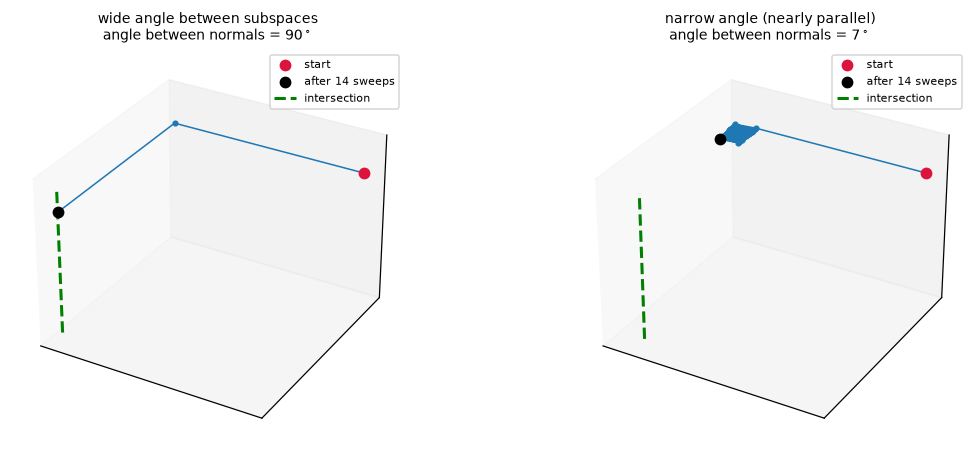

In [95]:
def alternating_path(n1, n2, start, n_steps):
    '''Project alternately onto plane1 = {v: n1.v = 0} and plane2 = {v: n2.v = 0}.'''
    n1, n2 = n1 / np.linalg.norm(n1), n2 / np.linalg.norm(n2)
    v, path = start.astype(float).copy(), [start.astype(float).copy()]
    for _ in range(n_steps):
        v = v - np.dot(n1, v) * n1; path.append(v.copy())
        v = v - np.dot(n2, v) * n2; path.append(v.copy())
    return np.array(path)

# Two geometries: planes meeting at a wide angle vs a narrow one.
cases = {"wide angle between subspaces": (np.array([1.0, 0, 0]), np.array([0, 1.0, 0.0])),
         "narrow angle (nearly parallel)": (np.array([1.0, 0, 0]),
                                            np.array([np.cos(0.12), np.sin(0.12), 0.0]))}

fig = plt.figure(figsize=(11, 4.2))
for k, (title, (n1, n2)) in enumerate(cases.items()):
    path = alternating_path(n1, n2, np.array([1.0, 1.0, 1.0]), 14)
    ang = np.degrees(np.arccos(abs(np.dot(n1 / np.linalg.norm(n1),
                                          n2 / np.linalg.norm(n2)))))
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.plot(path[:, 0], path[:, 1], path[:, 2], "o-", ms=3, lw=1, color="tab:blue")
    ax.scatter(*path[0], c="crimson", s=45, label="start")
    ax.scatter(*path[-1], c="k", s=45, label="after 14 sweeps")
    # the intersection line (kernel of both)
    d = np.cross(n1, n2); d = d / np.linalg.norm(d)
    tl = np.linspace(-1.5, 1.5, 2)[:, None] * d
    ax.plot(tl[:, 0], tl[:, 1], tl[:, 2], "g--", lw=2, label="intersection")
    ax.set_title(f"{title}\nangle between normals = {ang:.0f}$^\\circ$", fontsize=9)
    ax.legend(fontsize=7); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.tight_layout(); plt.show()

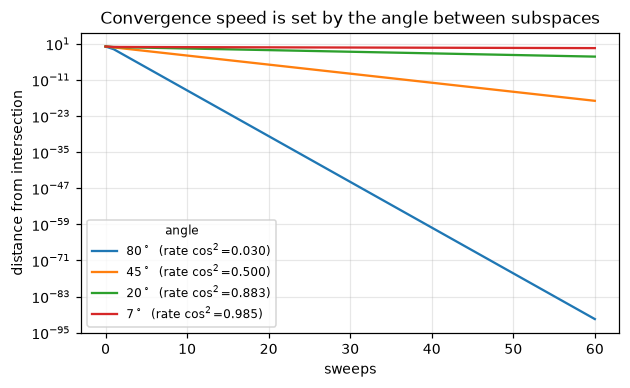

In [96]:
# Convergence rate as a function of the angle: this is Lemma 4.1's c = prod cos^2.
fig, ax = plt.subplots(figsize=(5.8, 3.6))
for angle_deg in [80, 45, 20, 7]:
    a = np.radians(angle_deg)
    n1, n2 = np.array([1.0, 0, 0]), np.array([np.cos(a), np.sin(a), 0.0])
    path = alternating_path(n1, n2, np.array([1.0, 1.0, 1.0]), 60)
    d = np.cross(n1, n2); d = d / np.linalg.norm(d)
    # distance from the intersection line
    err = [np.linalg.norm(v - np.dot(v, d) * d) for v in path[::2]]
    ax.semilogy(err, label=f"{angle_deg}$^\\circ$  (rate $\\cos^2$={np.cos(a)**2:.3f})")
ax.set_xlabel("sweeps"); ax.set_ylabel("distance from intersection")
ax.set_title("Convergence speed is set by the angle between subspaces")
ax.legend(fontsize=8, title="angle", title_fontsize=8)
plt.tight_layout(); plt.show()

The geometry is the whole story: **when subspaces meet at a shallow angle,
alternating projections crawl.** At $7^\circ$ the rate is $\cos^2 7^\circ = 0.985$,
so each sweep removes only 1.5% of the error.

Real per-batch Jacobian kernels are *very* nearly parallel — different batches of
similar data constrain similar directions. So we should expect slow convergence
in practice, and in section 6 we measure exactly how slow.

---
## 4. Matrix-free: JVPs and VJPs

One piece is still missing. A single projection step is

$$v \;\leftarrow\; v - J_b^\top (J_b J_b^\top)^{-1} J_b\, v$$

and we promised never to build $J_b$. We don't have to, because we only ever need
$J_b$ *applied to a vector*. Automatic differentiation gives both directions:

| operation | what it computes | cost |
|---|---|---|
| **JVP** (forward mode) `jvp(f, θ, v)` | $J v$ — push a weight-direction to output space | ~1 forward pass |
| **VJP** (reverse mode) `vjp(f, θ)(w)` | $J^\top w$ — pull an output-direction back to weights | ~1 backward pass |

A backprop call is exactly a VJP with $w$ = the gradient of the loss. So the
projection step is: one JVP, a tiny $R \times R$ solve, one VJP. Three cheap
operations instead of an $N \times P$ matrix.

We also need $J_b J_b^\top$ ($R \times R$, small). Column $j$ of it is
$J_b(J_b^\top e_j)$ — one VJP then one JVP. So the whole matrix costs $2R$ passes,
versus the $P$ passes it would take to write down $J_b$. With $R \approx 16$ and
$P \approx 10^6$ that's the difference between feasible and not.

Instead of inverting, we eigendecompose and use a **pseudo**-inverse (dropping
near-zero eigenvalues), because $J_b J_b^\top$ is often rank-deficient. Here is
the actual repo code, with one deliberate change from the reference
implementation flagged.

In [97]:
# ---- this mirrors llmproj/projection.py, at demo size ----
S = 6                                    # projection batch size
batches = [(x_train[i:i + S], y_train[i:i + S]) for i in range(0, N, S)]

def f_batch_factory(xb, yb):
    '''One scalar per datum -> the rows of the Jacobian we project against.'''
    return lambda th: (f_model(th, xb).squeeze(-1) - yb.squeeze(-1))

def build_JJt(f_b, R):
    '''J J^T, matrix-free: column j is J (J^T e_j). Costs 2R passes.'''
    eye = torch.eye(R)
    cols = []
    for j in range(R):
        _, vjp_fn = vjp(f_b, theta_map)
        jt_e = flatten(vjp_fn(eye[j])[0])            # J^T e_j   (a VJP)
        _, jjt_e = jvp(f_b, (theta_map,), (unflatten(jt_e),))   # J (...)  (a JVP)
        cols.append(jjt_e)
    return torch.stack(cols, dim=1)

def factorise(f_b, R, rtol=1e-6):
    M = build_JJt(f_b, R)
    M = 0.5 * (M + M.T)                              # symmetrise round-off
    ev, V = torch.linalg.eigh(M)
    # NOTE: the reference JAX code uses an ABSOLUTE cutoff of 1e-3 here. We use a
    # RELATIVE one. Loss-gradient magnitudes for an LLM differ from a toy MLP by
    # many orders of magnitude, so an absolute threshold silently keeps numerical
    # noise or throws away real directions.
    keep = ev > rtol * ev.max().clamp(min=0)
    inv = torch.where(keep, 1.0 / torch.where(keep, ev, torch.ones_like(ev)),
                      torch.zeros_like(ev))
    return V, inv, int(keep.sum())

factors = []
for xb, yb in batches:
    f_b = f_batch_factory(xb, yb)
    factors.append(factorise(f_b, xb.shape[0]))
print(f"{len(batches)} batches of size {S}; per-batch ranks: {[f[2] for f in factors]}")
print(f"total retained rows = {sum(f[2] for f in factors)},  P = {P}")

# The intersection's dimension is NOT P - sum(ranks): the batches constrain
# overlapping directions, so we must orthogonalise their union to count it.
retained = []
for (xb, yb), (V, inv, r) in zip(batches, factors):
    f_b = f_batch_factory(xb, yb)
    eye = torch.eye(xb.shape[0])
    Jb = torch.stack([flatten(vjp(f_b, theta_map)[1](eye[j])[0]) for j in range(xb.shape[0])])
    keep = inv > 0
    retained.append(V[:, keep].T @ Jb)
Q_union = torch.linalg.qr(torch.cat(retained).T)[0]
kernel_proj_exact = torch.eye(P) - Q_union @ Q_union.T
print(f"union of retained row spaces has rank {Q_union.shape[1]}"
      f"  ->  true dim of the intersection = {P - Q_union.shape[1]}")

10 batches of size 6; per-batch ranks: [6, 5, 5, 6, 5, 6, 6, 6, 5, 6]
total retained rows = 56,  P = 321
union of retained row spaces has rank 56  ->  true dim of the intersection = 265


In [98]:
def batch_project(v, xb, yb, V, inv):
    '''v <- (I - J^T (J J^T)^+ J) v for one batch.'''
    f_b = f_batch_factory(xb, yb)
    _, jv = jvp(f_b, (theta_map,), (unflatten(v),))      # J v
    w = V @ (inv * (V.T @ jv))                           # (J J^T)^+ J v
    _, vjp_fn = vjp(f_b, theta_map)
    return v - flatten(vjp_fn(w)[0])                     # v - J^T (...)

def project(v, n_sweeps, acceleration=True):
    for _ in range(n_sweeps):
        v_start = v
        for (xb, yb), (V, inv, _) in zip(batches, factors):
            v = batch_project(v, xb, yb, V, inv)
        if acceleration:
            # von Neumann acceleration: extrapolate along the sweep direction.
            d = v_start - v; dd = d @ d
            if dd > 0:
                t = (v_start @ d) / dd
                v = t * v + (1.0 - t) * v_start
    return v

def residual(v):
    '''||J v|| / ||v||: how far v still is from the kernel. Lower = better.'''
    tot = 0.0
    for xb, yb in batches:
        _, jv = jvp(f_batch_factory(xb, yb), (theta_map,), (unflatten(v),))
        tot += float((jv ** 2).sum())
    return tot ** 0.5 / float(v.norm())

def row_space_basis(xb, yb):
    # orthonormal basis of one batch's Jacobian row space (for angles)
    f_b = f_batch_factory(xb, yb)
    eye = torch.eye(xb.shape[0])
    Jb = torch.stack([flatten(vjp(f_b, theta_map)[1](eye[j])[0])
                      for j in range(xb.shape[0])])
    return torch.linalg.qr(Jb.T)[0]

eps0 = torch.randn(P, generator=torch.Generator().manual_seed(5))
print(f"before projecting: residual = {residual(eps0):.3e}")
print(f"after  10 sweeps : residual = {residual(project(eps0.clone(), 10)):.3e}")

before projecting: residual = 1.748e+00
after  10 sweeps : residual = 1.398e-02


---
## 5. The LLM twist: when the output dimension explodes

Everything so far projects onto $\ker(J)$, where $J$ has **one row per (datum,
output dimension)** pair. That per-batch inverse is $SO \times SO$.

For regression with one output, $O = 1$: fine. For 10-class classification,
$O = 10$: fine. For a language model, $O$ is the number of logits the network
emits for one training sequence:

$$O = \text{sequence length} \times \text{vocabulary size}$$

In [99]:
vocab, seq_len = 49_152, 512      # SmolLM2's tokenizer, a modest context
O = seq_len * vocab
print(f"SmolLM2:  O = {seq_len} x {vocab:,} = {O:,} outputs per sequence")
for S_ in (1, 8):
    n = S_ * O
    print(f"  batch of {S_:>2}: the inverse is {n:,} x {n:,}"
          f"  ->  {n**2 * 4 / 1024**4:,.0f} TB in fp32")

SmolLM2:  O = 512 x 49,152 = 25,165,824 outputs per sequence
  batch of  1: the inverse is 25,165,824 x 25,165,824  ->  2,304 TB in fp32
  batch of  8: the inverse is 201,326,592 x 201,326,592  ->  147,456 TB in fp32


Not "slow" — arithmetically impossible. This is why the paper's headline method
**cannot** be applied to a language model, and why §4.1 exists.

### The loss-Jacobian

Instead of preserving the *predictions* at each training point, preserve the
**loss** at each training point. Stack the per-datum loss gradients (Eq. 14):

$$J^L_\theta = \begin{bmatrix} \nabla_\theta\, \ell(f(\theta,x_1), y_1) \\ \vdots \\ \nabla_\theta\, \ell(f(\theta,x_N), y_N) \end{bmatrix} \in \mathbb{R}^{N \times P}$$

One row per datum, not $O$ rows. The output dimension vanishes from the row count.

Why is this legitimate? Because the loss gradient is a *linear combination* of
that datum's Jacobian rows:
$\nabla_\theta \ell = \nabla_f \ell \cdot J_\theta(x)$. So each datum's $O$ rows
get collapsed into one meaningful row — meaningful because it's weighted by how
the loss actually responds. Formally (Lemma 4.2):

$$\ker(J_\theta) \subseteq \ker(J^L_\theta)$$

The kernel gets *bigger*, so the guarantee gets weaker: instead of "predictions
exactly preserved" we get "**loss** preserved to first order" (Lemma 4.3):

$$\big|\ell(f(\theta,x_n),y_n) - \ell(f(\theta_{\text{map}},x_n),y_n)\big| = O(\|\theta - \theta_{\text{map}}\|^2)$$

For the "we don't underfit" claim, that's exactly what we need.

### Lemma 4.2, concretely: swapping predictions for loss

Lemma 4.2 says $\ker(J_\theta) \subseteq \ker(J^L_\theta)$, and adds a detail that
matters for us: *the two are identical when $O = 1$*. Our regression toy has one
output, so it cannot show the difference at all. We need a multi-output model.

So here is a 3-class classifier. Now $J$ has $N \times O = 3N$ rows (one per
datum per class) while $J^L$ has only $N$. The loss-kernel is strictly bigger, and
we can find a direction that lives in it but *not* in the prediction-kernel. Such a
direction should **change the logits while leaving every per-datum loss alone** —
which is precisely the trade the paper makes to escape the $O$ blow-up.

In [100]:
torch.manual_seed(7)
Nc, Oc = 24, 3
xc = torch.randn(Nc, 2)
yc = (xc[:, 0] + xc[:, 1] > 0).long() + (xc[:, 0] > 0.5).long()   # 3 classes
clf = nn.Sequential(nn.Linear(2, 12), nn.Tanh(), nn.Linear(12, Oc))
oc = torch.optim.Adam(clf.parameters(), lr=5e-2)
for _ in range(1200):
    l = nn.functional.cross_entropy(clf(xc), yc)
    oc.zero_grad(); l.backward(); oc.step()

cnames = [n for n, _ in clf.named_parameters()]
tc = {n: q.detach().clone() for n, q in clf.named_parameters()}
cshapes = [tc[n].shape for n in cnames]
cnumels = [tc[n].numel() for n in cnames]
Pc = sum(cnumels)

def unf_c(v):
    o, i = {}, 0
    for n, s, ne in zip(cnames, cshapes, cnumels):
        o[n] = v[i:i + ne].view(s); i += ne
    return o

def logits_c(th):
    return functional_call(clf, th, (xc,)).reshape(-1)          # (Nc*Oc,)

def perdatum_loss_c(th):
    return nn.functional.cross_entropy(functional_call(clf, th, (xc,)), yc,
                                       reduction="none")        # (Nc,)

def jac_of(fn):
    rows = []
    for k in range(Pc):
        e = torch.zeros(Pc); e[k] = 1.0
        _, jv = jvp(fn, (tc,), (unf_c(e),))
        rows.append(jv)
    return torch.stack(rows, dim=1)

Jfull = jac_of(logits_c)            # (Nc*Oc, Pc)  -- the PREDICTION Jacobian
JL = jac_of(perdatum_loss_c)        # (Nc,    Pc)  -- the LOSS Jacobian
print(f"P = {Pc};   J has shape {tuple(Jfull.shape)};   J^L has shape {tuple(JL.shape)}")

def kernel_projector(M, rtol=1e-8):
    _, s, Vh = torch.linalg.svd(M, full_matrices=False)
    keep = s > rtol * s.max()
    V = Vh[keep]
    return torch.eye(Pc) - V.T @ V, int(keep.sum())

Pk_full, r_full = kernel_projector(Jfull)
Pk_loss, r_loss = kernel_projector(JL)
print(f"dim ker(J)   = {Pc - r_full}    (predictions preserved)")
print(f"dim ker(J^L) = {Pc - r_loss}    (only the loss preserved)")
print(f"the loss-kernel is {(Pc - r_loss) - (Pc - r_full)} dimensions bigger")

# containment check: project a ker(J) vector into ker(J^L) and see if it moves
gg = torch.Generator().manual_seed(4)
v_in_kerJ = Pk_full @ torch.randn(Pc, generator=gg)
leak = float((v_in_kerJ - Pk_loss @ v_in_kerJ).norm() / v_in_kerJ.norm())
print(f"\nLemma 4.2 check: a vector in ker(J), re-projected into ker(J^L),")
print(f"moves by a relative {leak:.3e}  ->  ker(J) really does sit inside ker(J^L)")

# a direction in ker(J^L) but NOT in ker(J)
d = Pk_loss @ torch.randn(Pc, generator=gg)
d = d - Pk_full @ d
d = d / d.norm() * 1e-3
print(f"\nnow take delta in ker(J^L) but orthogonal to ker(J), ||delta|| = {d.norm():.1e}")

P = 75;   J has shape (72, 75);   J^L has shape (24, 75)
dim ker(J)   = 3    (predictions preserved)
dim ker(J^L) = 51    (only the loss preserved)
the loss-kernel is 48 dimensions bigger

Lemma 4.2 check: a vector in ker(J), re-projected into ker(J^L),
moves by a relative 2.903e-10  ->  ker(J) really does sit inside ker(J^L)

now take delta in ker(J^L) but orthogonal to ker(J), ||delta|| = 1.0e-03


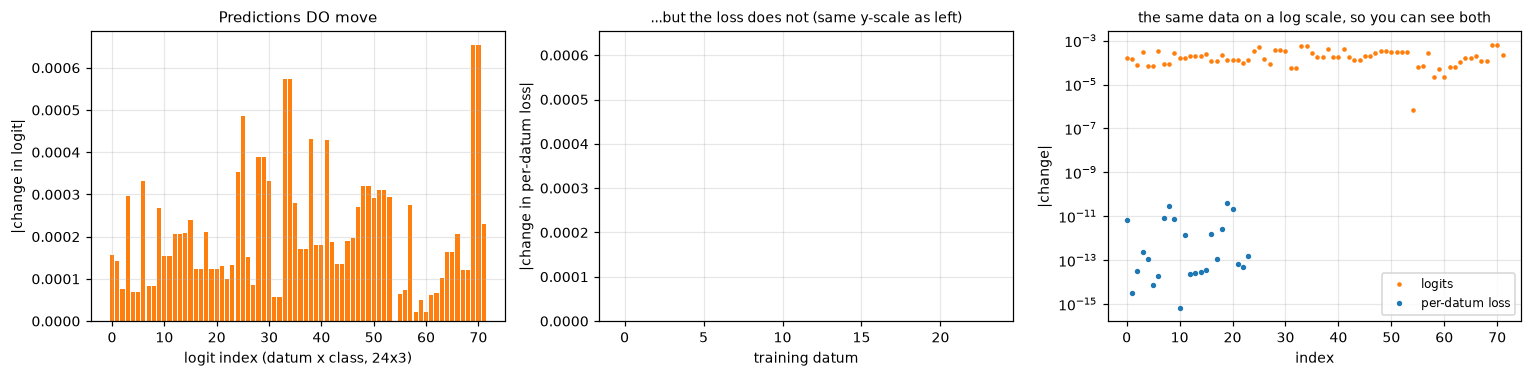

max |change in logit|            : 6.535e-04
max |change in per-datum loss|   : 4.139e-11
ratio                            : 15,790,074x


In [101]:
base_logits = logits_c(tc).detach()
base_losses = perdatum_loss_c(tc).detach()
th_p = {n: tc[n] + v for n, v in unf_c(d).items()}
dlogit = (logits_c(th_p).detach() - base_logits).abs()
dloss = (perdatum_loss_c(th_p).detach() - base_losses).abs()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].bar(range(len(dlogit)), dlogit.numpy(), color="tab:orange")
ax[0].set_xlabel(f"logit index (datum x class, {Nc}x{Oc})")
ax[0].set_ylabel("|change in logit|")
ax[0].set_title("Predictions DO move", fontsize=10)

ax[1].bar(range(len(dloss)), dloss.numpy(), color="tab:blue")
ax[1].set_xlabel("training datum")
ax[1].set_ylabel("|change in per-datum loss|")
ax[1].set_ylim(0, max(float(dlogit.max()), 1e-12))     # SAME scale as the left
ax[1].set_title("...but the loss does not (same y-scale as left)", fontsize=9)

ax[2].semilogy(dlogit.numpy(), ".", ms=4, color="tab:orange", label="logits")
ax[2].semilogy(dloss.numpy(), ".", ms=5, color="tab:blue", label="per-datum loss")
ax[2].set_xlabel("index"); ax[2].set_ylabel("|change|")
ax[2].set_title("the same data on a log scale, so you can see both", fontsize=9)
ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"max |change in logit|            : {dlogit.max():.3e}")
print(f"max |change in per-datum loss|   : {dloss.max():.3e}")
print(f"ratio                            : {dlogit.max() / dloss.max():,.0f}x")

The two panels are drawn on the **same vertical scale**, which is the whole point.
The logits move by a visible amount; the per-datum losses move by an amount
thousands of times smaller. We bought a bigger kernel — more room for the
posterior — by weakening the promise from "your predictions are untouched" to
"your loss is untouched".

For an LLM that trade is not optional, it is the only way in: it is what turns a
$25{,}165{,}824$-row-per-sequence Jacobian into a one-row-per-sequence one.

And it is a *sensible* trade for the underfitting argument, because underfitting
was always defined in terms of loss. If every training point keeps its loss, the
Bayesian predictive cannot be worse-fitting than $\theta_{map}$, whatever happened
to the individual logits.

### One row per sequence, or one per token?

For a language model there's a genuine choice the paper doesn't address, because
it never considers sequence models. Our `make_causal_lm_loss` implements both:

| `mode` | rows of $J^L$ | cost | kernel |
|---|---|---|---|
| `"sequence"` | $N$ (mean NLL per sequence) | cheapest, matches Eq. 14 | largest |
| `"token"` | $N \cdot T$ (each token's NLL) | $T\times$ more | tighter, stronger guarantee |

Section 6 gives a concrete reason to prefer `"token"` that has nothing to do with
the guarantee.

---
## 6. What we found

Five results from implementing this. Two of them should change how you use the
method.

### 6.1 Alternating projections can stall completely

On a small problem we can compute the exact intersection projector directly, so
we can check what the iterative algorithm actually converges to. One subtlety: we
must compare against the intersection of the *per-batch* kernels **at the same
tolerance the batches use**. Comparing against a global SVD at a different cutoff
would be measuring the wrong subspace.

acceleration=True (our default)
 sweeps    residual   rel err vs exact    cos angle
      0   1.748e+00          4.203e-01   0.92187806
      1   1.045e-02          3.958e-01   0.92981615
      5   1.163e-02          3.943e-01   0.93028286
     20   7.009e-03          3.813e-01   0.93437897
    100   1.450e-02          3.728e-01   0.93699458
    400   5.831e-03          3.593e-01   0.94108384
   1500   9.770e-03          3.410e-01   0.94649053

for reference, the exact projector has residual 8.71e-16


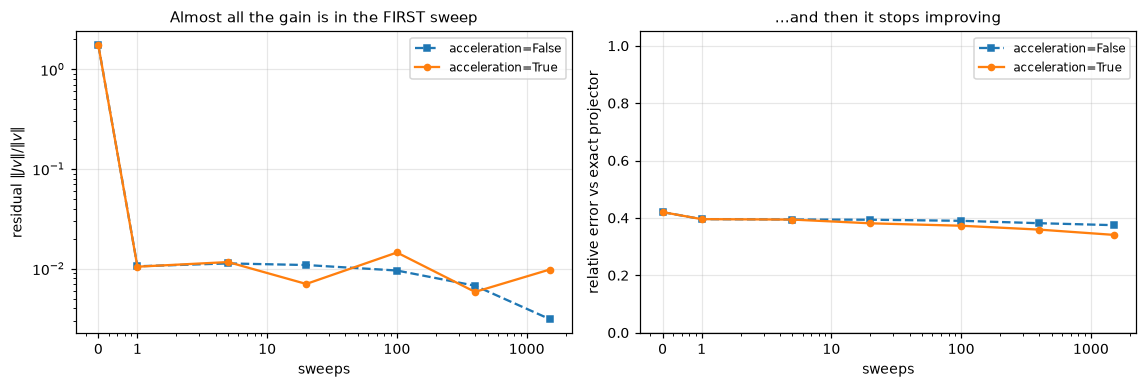

In [102]:
exact = kernel_proj_exact @ eps0
SWEEPS = [0, 1, 5, 20, 100, 400, 1500]

def trace(acceleration):
    out = []
    for n_sweeps in SWEEPS:
        v = eps0.clone() if n_sweeps == 0 else project(eps0.clone(), n_sweeps,
                                                       acceleration=acceleration)
        out.append((n_sweeps, residual(v),
                    float((v - exact).norm() / exact.norm()),
                    float((v @ exact) / (v.norm() * exact.norm()))))
    return out

tr_on, tr_off = trace(True), trace(False)

print("acceleration=True (our default)")
print(f"{'sweeps':>7} {'residual':>11} {'rel err vs exact':>18} {'cos angle':>12}")
for s, r, e, c in tr_on:
    print(f"{s:7d} {r:11.3e} {e:18.3e} {c:12.8f}")
print(f"\nfor reference, the exact projector has residual {residual(exact):.2e}")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
xs = [max(s, 0.5) for s in SWEEPS]          # 0 plotted at 0.5 so log axis works

for tr, lbl, style in [(tr_off, "acceleration=False", "s--"),
                       (tr_on, "acceleration=True", "o-")]:
    ax[0].loglog(xs, [r[1] for r in tr], style, label=lbl, ms=4)
ax[0].set_xticks([0.5, 1, 10, 100, 1000])
ax[0].set_xticklabels(["0", "1", "10", "100", "1000"])
ax[0].set_xlabel("sweeps"); ax[0].set_ylabel(r"residual $\|Jv\|/\|v\|$")
ax[0].set_title("Almost all the gain is in the FIRST sweep", fontsize=10)
ax[0].legend(fontsize=8)

for tr, lbl, style in [(tr_off, "acceleration=False", "s--"),
                       (tr_on, "acceleration=True", "o-")]:
    ax[1].semilogx(xs, [r[2] for r in tr], style, label=lbl, ms=4)
ax[1].set_xticks([0.5, 1, 10, 100, 1000])
ax[1].set_xticklabels(["0", "1", "10", "100", "1000"])
ax[1].set_ylim(0, 1.05)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("sweeps"); ax[1].set_ylabel("relative error vs exact projector")
ax[1].set_title("...and then it stops improving", fontsize=10)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Look at the sweep-0 row first, because it reframes everything.

Before any projection the residual is $\approx 1.7$. **One** sweep takes it to
$\approx 10^{-2}$ — a factor of ~170. Then 1499 further sweeps buy less than
another factor of 4, and with acceleration on it doesn't even decrease
monotonically (the extrapolation step can overshoot). So the left panel is not
"steady convergence"; it is one big drop followed by a flat, noisy floor.

The right panel is the damning one. The **relative error against the exact
projector** begins at $\approx 0.42$ and, after 1500 sweeps, has reached only
$\approx 0.34$. That is essentially a flat line: the first sweep does not help it,
and neither do the next 1499. The iterate is *not* converging to the right
subspace on this problem, and more compute will not rescue it.

Which also shows why the residual is a treacherous diagnostic on its own. It fell
by a factor of 170 while the quantity we actually care about barely budged.

Is the implementation wrong? No. The repository's test suite contains
`test_converges_to_exact_projector`, which on a well-conditioned problem reaches
cos angle $1.0000000$ and relative error $7 \times 10^{-7}$. The code is right.
**The geometry is the problem** — and Lemma 4.1 tells us exactly which quantity
to blame.

In [103]:
# Lemma 4.1's rate is c = prod_b cos^2(theta_b), with theta_b the smallest angle
# between batch b's row space and the others. Let's just measure it, over all pairs.
import itertools

bases = [row_space_basis(xb, yb) for xb, yb in batches]

cos2 = []
for Qi, Qj in itertools.combinations(bases, 2):
    smax = float(torch.linalg.svdvals(Qi.T @ Qj).clamp(max=1.0).max())
    cos2.append(smax ** 2)
cos2 = np.array(cos2)

print(f"{'pair':>7} {'smallest angle':>18} {'cos^2':>10}")
for (i, j), c in list(zip(itertools.combinations(range(len(bases)), 2), cos2))[:6]:
    print(f"  {i}-{j:<3} {np.degrees(np.arccos(np.sqrt(c))):14.4f} deg {c:10.6f}")

med = float(np.median(cos2))
print(f"\nmedian cos^2 over all {len(cos2)} pairs = {med:.6f}")
print(f"per-sweep error reduction factor      ~ {med:.6f}")
if med < 1 - 1e-9:
    print(f"sweeps for a 10x error reduction      ~ {np.log(0.1) / np.log(med):,.0f}")
else:
    print("sweeps for a 10x error reduction      ~ effectively unbounded")

   pair     smallest angle      cos^2
  0-1           0.0016 deg   1.000000
  0-2           0.0002 deg   1.000000
  0-3           0.0000 deg   1.000000
  0-4           0.0000 deg   1.000000
  0-5           0.0001 deg   1.000000
  0-6           0.0004 deg   1.000000

median cos^2 over all 45 pairs = 1.000000
per-sweep error reduction factor      ~ 1.000000
sweeps for a 10x error reduction      ~ effectively unbounded


There it is. The smallest angle between per-batch row spaces is **essentially
zero** — thousandths of a degree — so $\cos^2\theta_b = 1.000000$, the rate is
$1$, and the algorithm makes no progress. No iteration budget fixes this.

**Why?** We trained a network to fit a *smooth, one-dimensional* function. The
per-datum Jacobians $J(x_n)$ for nearby inputs are nearly collinear — a smooth 1-D
function simply has few independent directions in which it can change. So every
batch constrains nearly the same directions, the subspaces are nearly identical,
and von Neumann's algorithm has nothing to alternate between.

That is a very different regime from the paper's targets (vision transformers on
image classification), where different batches genuinely constrain different
directions and the reported results are strong. **Whether the method is viable
depends on the geometry of your data, and the residual alone will not tell you.**
For sequence data — where adjacent tokens are highly correlated — this is a real
risk worth checking before committing to the iterative route.

Three takeaways:

1. **The residual is necessary but not sufficient.** It can look small while the
   iterate sits in the wrong subspace. Treat it as a lower bound on trouble, not
   a certificate.
2. **Measure the principal angles first.** It costs a handful of QR
   decompositions and it predicts the entire compute budget.
3. **Prefer the exact SVD path whenever it fits** (§6.4). It sidesteps this
   entirely — not merely faster, but the only reliable option in this geometry.

### 6.2 The $\alpha$ scaling trap — the finding most likely to bite you

Lemma 3.4 gives the prior precision in closed form, no optimisation needed:

$$\alpha^* = \frac{\|\theta_{\text{map}}\|^2}{P - \operatorname{Tr}(I - \mathcal{P}(\text{GGN}))} = \frac{\|\theta_{\text{map}}\|^2}{\operatorname{rank}(J^L)}$$

Look at that denominator. Under `mode="sequence"`, $\operatorname{rank}(J^L) = N$
— just the number of training sequences. When $P \gg N$ (always, for LoRA), the
denominator is tiny, so $\alpha^*$ is tiny, so the posterior is **enormous**.

A sample has norm $\approx \sqrt{P/\alpha}$. Plug in our real measurement from the
LoRA smoke test ($P = 2048$, $N = 16$, $\alpha^* = 0.64$) and you get
$\|\delta\| \approx 57$. That is nowhere near the linear regime where Lemma 4.3
applies — so the guarantee evaporates, and projected samples degrade the loss
about as badly as isotropic ones.

In [104]:
theta_norm_sq = float(sum((t ** 2).sum() for t in theta_map.values()))

# First: measure where the linear regime actually ends on this problem, by
# walking out along a kernel direction until the train loss moves by >10%.
v_k = kernel_proj_exact @ eps0
v_k = v_k / v_k.norm()
limit = np.nan
for nrm in np.logspace(-4, 1, 60):
    th = {n: theta_map[n] + v for n, v in unflatten(v_k * float(nrm)).items()}
    if abs(train_mse(th) - base) > 0.10 * base:
        limit = nrm
        break

print(f"||theta_map||^2 = {theta_norm_sq:.3f},  P = {P}")
print(f"measured linear-regime limit: ||delta|| < {limit:.3g}"
      f"   (where train MSE moves by 10%)\n")
print(f"{'rank(J^L)':>10} {'alpha*':>12} {'implied ||delta||':>18}  verdict")
for r_ in sorted({len(batches), N, 4 * N, P // 2, P}):
    a = theta_norm_sq / max(r_, 1)
    nrm = (P / a) ** 0.5
    print(f"{r_:10d} {a:12.4e} {nrm:18.3f}  "
          f"{'OK' if nrm < limit else 'outside linear regime'}")
print("\nmode='sequence' puts rank(J^L) = N, at the top of this table.")
print("mode='token' multiplies it by the sequence length T, moving you down.")

||theta_map||^2 = 60.104,  P = 321
measured linear-regime limit: ||delta|| < 0.441   (where train MSE moves by 10%)

 rank(J^L)       alpha*  implied ||delta||  verdict
        10   6.0104e+00              7.308  outside linear regime
        60   1.0017e+00             17.901  outside linear regime
       160   3.7565e-01             29.232  outside linear regime
       240   2.5043e-01             35.802  outside linear regime
       321   1.8724e-01             41.405  outside linear regime

mode='sequence' puts rank(J^L) = N, at the top of this table.
mode='token' multiplies it by the sequence length T, moving you down.


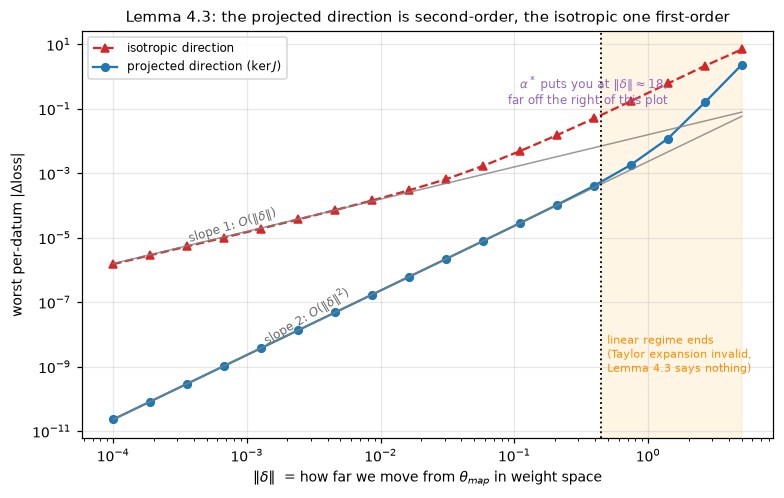

at ||delta|| = 8.6e-03:
   isotropic  worst |dloss| = 1.430e-04
   projected  worst |dloss| = 1.722e-07
   projection is 831x gentler on the training loss


In [105]:
# Compare at MATCHED ||delta||: that is the only regime where Lemma 4.3 speaks.
# NOTE: we use the EXACT kernel projector here, not the iterative one -- section 6.1
# showed the iteration does not converge on this problem, so its output is not
# actually in the kernel and would muddy the comparison.
v_ker = kernel_proj @ eps0
v_ker = v_ker / v_ker.norm()
v_rnd = torch.randn(P, generator=torch.Generator().manual_seed(9))
v_rnd = v_rnd / v_rnd.norm()

def worst_perdatum_change(u, scale):
    # Lemma 4.3 is a statement about EACH datum, so track the worst one.
    th = {n: theta_map[n] + v for n, v in unflatten(u * float(scale)).items()}
    before = ((f_model(theta_map, x_train) - y_train) ** 2).squeeze(-1)
    after = ((f_model(th, x_train) - y_train) ** 2).squeeze(-1)
    return max(float((after - before).abs().max()), 1e-18)

norms = np.logspace(-4, 0.7, 18)
c_ker = [worst_perdatum_change(v_ker, s) for s in norms]
c_rnd = [worst_perdatum_change(v_rnd, s) for s in norms]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.loglog(norms, c_rnd, "^--", color="tab:red", label="isotropic direction", ms=5)
ax.loglog(norms, c_ker, "o-", color="tab:blue", label=r"projected direction ($\ker J$)", ms=5)

# reference slopes, anchored to pass near each curve
ax.loglog(norms, c_rnd[6] * (norms / norms[6]) ** 1, "-", color="grey", lw=1, alpha=0.8)
ax.loglog(norms, c_ker[10] * (norms / norms[10]) ** 2, "-", color="grey", lw=1, alpha=0.8)
ax.annotate("slope 1: $O(\\|\\delta\\|)$", (norms[2], c_rnd[6] * (norms[2] / norms[6])),
            fontsize=8, color="dimgrey", rotation=17, va="bottom")
ax.annotate("slope 2: $O(\\|\\delta\\|^2)$",
            (norms[4], c_ker[10] * (norms[4] / norms[10]) ** 2),
            fontsize=8, color="dimgrey", rotation=31, va="bottom")

ax.axvline(limit, color="k", ls=":", lw=1.2)
ax.axvspan(limit, norms[-1], color="orange", alpha=0.10)
ax.annotate("linear regime ends\n(Taylor expansion invalid,\nLemma 4.3 says nothing)",
            (limit * 1.12, min(c_ker) * 30), fontsize=7.5, color="darkorange")

alpha_star_norm = (P / (theta_norm_sq / N)) ** 0.5
if alpha_star_norm <= norms[-1]:
    ax.axvline(alpha_star_norm, color="tab:purple", ls="-.", lw=1.2)
else:
    ax.annotate(f"$\\alpha^*$ puts you at $\\|\\delta\\|\\approx${alpha_star_norm:.0f},\n"
                "far off the right of this plot",
                (norms[-1] * 0.28, max(c_rnd) * 0.02), fontsize=8, color="tab:purple",
                ha="right")

ax.set_xlabel(r"$\|\delta\|$  = how far we move from $\theta_{map}$ in weight space")
ax.set_ylabel(r"worst per-datum $|\Delta \mathrm{loss}|$")
ax.set_title("Lemma 4.3: the projected direction is second-order, the isotropic one first-order",
             fontsize=9.5)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

i = int(np.argmin(np.abs(norms - 1e-2)))
print(f"at ||delta|| = {norms[i]:.1e}:")
print(f"   isotropic  worst |dloss| = {c_rnd[i]:.3e}")
print(f"   projected  worst |dloss| = {c_ker[i]:.3e}")
print(f"   projection is {c_rnd[i] / c_ker[i]:,.0f}x gentler on the training loss")

#### How to read that plot

It repays a slow look, because it is Lemma 4.3 in a single picture.

- **The $x$-axis** is how far we step away from $\theta_{map}$, measured as the
  Euclidean norm $\|\delta\|$ in weight space. Left = a tiny nudge, right = a
  big jump.
- **The $y$-axis** is the damage that step does: across all training points, the
  largest change in that point's loss. Zero would mean "the training fit is
  completely untouched".
- **Both axes are logarithmic.** This is the important bit. On log-log axes a
  power law $y = C\,x^{k}$ becomes a *straight line of slope $k$*. So we are not
  reading off values here — we are reading off **exponents**, and the two grey
  guide lines have slope 1 and slope 2.

Now the two curves:

- The **isotropic** direction (red) follows **slope 1**. Double $\|\delta\|$ and
  you double the damage. The step has a non-zero component in the row space of
  $J$, so $J\delta \neq 0$ and the loss changes at *first* order.
- The **projected** direction (blue) follows **slope 2**. Double $\|\delta\|$ and
  the damage *quadruples* — which sounds worse until you notice it starts from a
  vastly lower base. Slope 2 is the signature of the first-order term being
  exactly zero: $J\delta = 0$, so all that remains is curvature. **That is
  Lemma 4.3.**

The vertical gap between the curves at any given $\|\delta\|$ is the practical
payoff, and because the slopes differ that gap *widens* as you step more finely.
At $\|\delta\| = 10^{-2}$ it is already several orders of magnitude.

One edge of the plot is an artefact rather than physics, and it is the important
one. On the **far right**, past the dotted line, the blue curve steepens sharply
and climbs toward the red. The linear regime has ended: the Taylor expansion the
whole argument rests on is no longer valid, so Lemma 4.3 makes no claim there, and
the projected direction loses its advantage. **This is exactly where $\alpha^*$
puts you** — the annotation shows it lands off the right edge entirely — and that
is the trap.

(We are running in float64 here, so both curves stay clean down to $10^{-11}$. In
fp32 the blue curve would flatten into a noise floor around $10^{-7}$; if you see
that in your own runs, it is arithmetic, not physics.)

Note that on *this* toy problem no row of the table escapes: with $P = 321$
and $\|\theta_{map}\|^2 \approx 58$, even a full-rank $J^L$ leaves
$\|\delta\| \approx 42$ against a measured linear-regime limit of $0.9$. That
is the trap in its most severe form: when $P$ is small and $\|\theta_{map}\|$ is
sizeable, Lemma 3.4 cannot produce a usable $\alpha$ at all. At realistic scale
the ratio is friendlier, but you must check it rather than assume it.

**Three ways out, in order of preference:**

1. **Use `mode="token"`.** Rank becomes $N \cdot T$ instead of $N$, which
   simultaneously tightens the kernel and lifts $\alpha^*$ by a factor of $T$.
   This is the strongest practical argument for the per-token variant.
2. **Increase $N$** until $\operatorname{rank}(J^L)$ is a real fraction of $P$.
3. **Set $\alpha$ by hand** and report a sensitivity sweep.

This is not a flaw in the paper. It targets $P \gg N \cdot O$ with $O$ *large*, so
$\operatorname{rank} = N \cdot O$ is substantial there. A causal LM under
per-sequence loss collapses $O$ to 1 — exactly where the closed form degenerates.

### 6.3 Estimating the kernel dimension: know the error bars

$\alpha^*$ needs $\operatorname{Tr}(I - \mathcal{P})$, the kernel dimension. We
don't have the matrix, but for a projector $\mathcal{P}$,

$$\varepsilon^\top \mathcal{P}\, \varepsilon \quad \text{with} \quad \varepsilon \sim \mathcal{N}(0, I)$$

is an unbiased estimate of $\operatorname{Tr}(\mathcal{P})$ — **Hutchinson's
estimator**. Just project a few random vectors and take inner products.

It's unbiased but noisy: $\operatorname{Var} = 2\operatorname{Tr}(\mathcal{P})$,
so $k$ probes give a standard deviation of $\sqrt{2\,\text{kernel dim}/k}$.

In [106]:
# Use a projector whose rank we know exactly, so we measure the ESTIMATOR's
# statistics and nothing else. (In the real pipeline the same estimator runs on
# the iterative projection, where convergence error adds bias on top of this.)
rank_true = 265
Qr = torch.linalg.qr(torch.randn(P, P - rank_true,
                                 generator=torch.Generator().manual_seed(1)))[0]
Pk_known = torch.eye(P) - Qr @ Qr.T          # a projector of rank exactly 265
print(f"synthetic projector: P = {P}, Tr(Pk) = {Pk_known.trace():.6f} "
      f"(exactly {rank_true})\n")

print(f"{'probes':>7} {'estimates over 3 seeds':>34} {'predicted std':>14}")
for k in [1, 4, 16, 64]:
    ests = []
    for seed in (0, 1, 2):
        gg = torch.Generator().manual_seed(seed)
        acc = 0.0
        for _ in range(k):
            e = torch.randn(P, generator=gg)
            acc += float(e @ (Pk_known @ e))
        ests.append(acc / k)
    print(f"{k:7d} {str([f'{e:.1f}' for e in ests]):>34} "
          f"{(2 * rank_true / k) ** 0.5:14.2f}")

print("\nRelative error is what matters, and it shrinks as the problem grows:")
for kd in [rank_true, 10_000, 1_000_000]:
    print(f"  kernel dim {kd:>9,}: 8 probes -> std {(2*kd/8)**0.5:9.1f}"
          f"  = {(2*kd/8)**0.5/kd*100:6.3f}% relative")

synthetic projector: P = 321, Tr(Pk) = 265.000000 (exactly 265)

 probes             estimates over 3 seeds  predicted std
      1        ['259.6', '295.1', '211.7']          23.02
      4        ['255.2', '273.0', '250.1']          11.51
     16        ['264.8', '263.6', '259.3']           5.76
     64        ['265.3', '267.0', '258.3']           2.88

Relative error is what matters, and it shrinks as the problem grows:
  kernel dim       265: 8 probes -> std       8.1  =  3.071% relative
  kernel dim    10,000: 8 probes -> std      50.0  =  0.500% relative
  kernel dim 1,000,000: 8 probes -> std     500.0  =  0.050% relative


The estimates scatter exactly as $\sqrt{2\,\text{rank}/k}$ predicts, and tighten
as $1/\sqrt{k}$. So a handful of probes is dangerously noisy on a small problem
but perfectly fine at LLM scale, where a kernel dimension of $10^6$ gets 0.05%
relative error from 8 probes. Good news for the real use case; a trap in unit
tests, which is why ours asserts a $4\sigma$ statistical bound rather than an
exact match.

### 6.4 If the dense $J^L$ fits in memory, don't iterate at all

Here's the finding that most changes day-to-day practice. $J^L$ has only $R$ rows
($R$ = training rows, **not** $N \cdot O$). So $J^{L\top}J^L$ is *low rank*, and
one SVD of the dense $J^L$ gives you:

- the **exact** kernel projector, $I - W^\top W$;
- full-covariance **linearised Laplace**, $(J^\top J + \alpha I)^{-1}$, in closed
  form — no KFAC, no last-layer approximation;
- **diagonal Laplace**, from $\operatorname{diag}(J^\top J)$, for free.

Measured on the tiny LoRA-adapted Llama ($P=2048$, $R=16$, 4 samples, 300 sweeps),
via `scripts/compare_methods.py`:

| method | time | kernel residual |
|---|---:|---:|
| diagonal Laplace | 0.9 s | 4.0e-02 |
| linearised Laplace (full covariance) | 0.9 s | 3.1e-02 |
| **projected, exact SVD** | **0.95 s** | **3.7e-08** |
| projected, alternating projections | 716 s | 4.1e-05 |

Both projected routes returned the same sample norm (78.02 vs 78.02), which is an
independent check that the iterative code is right. But the exact route was
**~750× faster** and hit machine precision.

The decision rule is memory, not accuracy:

In [107]:
def dense_J_gb(rows, P_, bytes_per=4):
    return rows * P_ * bytes_per / 1024 ** 3

print(f"{'setting':<44} {'rows R':>9} {'dense J^L':>12}  verdict")
for label, rows_, P_ in [
    ("LoRA, mode=sequence, N=256",                256,      2_000_000),
    ("LoRA, mode=sequence, N=4096",               4096,     2_000_000),
    ("LoRA, mode=token, N=256, T=256",            256 * 256, 2_000_000),
    ("full 135M model, mode=sequence, N=256",     256,      135_000_000),
]:
    gb = dense_J_gb(rows_, P_)
    verdict = "exact SVD" if gb < 8 else "alternating projections"
    print(f"{label:<44} {rows_:>9,} {gb:>9.1f} GB  {verdict}")

setting                                         rows R    dense J^L  verdict
LoRA, mode=sequence, N=256                         256       1.9 GB  exact SVD
LoRA, mode=sequence, N=4096                      4,096      30.5 GB  alternating projections
LoRA, mode=token, N=256, T=256                  65,536     488.3 GB  alternating projections
full 135M model, mode=sequence, N=256              256     128.7 GB  alternating projections


So for your first real experiments — sequence mode, a few hundred sequences,
LoRA-sized $P$ — you can skip alternating projections entirely and get the exact
answer in a second. The iterative algorithm earns its keep in token mode and at
full-model scale, which is precisely what it was designed for.

### 6.5 "Fully correlated" is visible in the covariance

The paper's title promises *fully correlated* posteriors. That's the contrast with
mean-field (diagonal) approximations, which assume every weight is independent.
Because we can build the covariance exactly from the SVD, we can just look.

Run `scripts/visualize_posterior.py --loss-mode token` for the full six-panel
figure on the real LoRA model. Here is the same idea at demo scale.

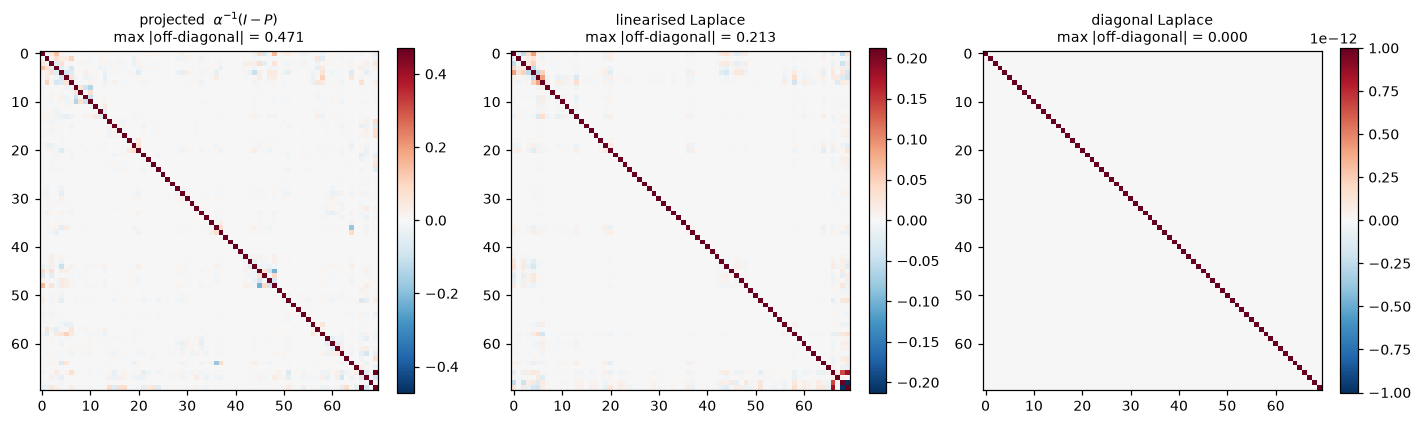

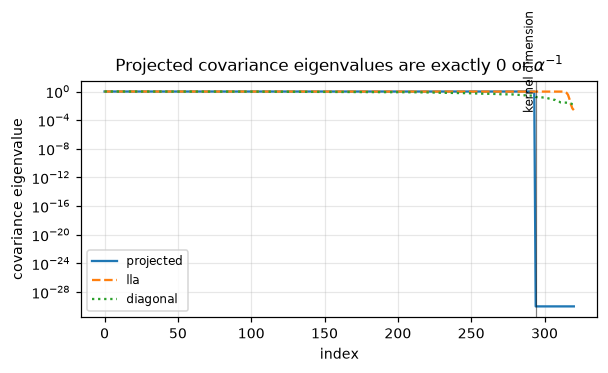

In [108]:
J_L = J                                     # for this scalar-output demo, J^L = J
_, s_, Wh = torch.linalg.svd(J_L, full_matrices=False)
keep = s_ > 1e-10 * s_.max()
s_, W_ = s_[keep], Wh[keep]
a_ = 1.0

k = 70
idx = torch.linspace(0, P - 1, k).long()
Ws = W_[:, idx]
I_k = torch.eye(k)
diag_full = (J_L ** 2).sum(0)

cov = {
    "projected  $\\alpha^{-1}(I-P)$": ((I_k - Ws.T @ Ws) / a_),
    "linearised Laplace": (I_k / a_ + Ws.T @ torch.diag((s_ ** 2 + a_).reciprocal() - 1 / a_) @ Ws),
    "diagonal Laplace": torch.diag(1.0 / (diag_full[idx] + a_)),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, (name, Cm) in zip(axes, cov.items()):
    Cn = Cm.numpy()
    d = np.sqrt(np.clip(np.diag(Cn), 1e-30, None))
    corr = Cn / np.outer(d, d)
    off = corr - np.diag(np.diag(corr))
    v = max(np.abs(off).max(), 1e-12)
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    ax.grid(False)
    ax.set_title(f"{name}\nmax |off-diagonal| = {np.abs(off).max():.3f}", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

ev_proj = np.concatenate([np.zeros(len(s_)), np.full(P - len(s_), 1 / a_)])
ev_lla = np.concatenate([(1 / (s_ ** 2 + a_)).numpy(), np.full(P - len(s_), 1 / a_)])
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.semilogy(np.sort(ev_proj)[::-1] + 1e-30, "-", label="projected")
ax.semilogy(np.sort(ev_lla)[::-1], "--", label="lla")
ax.semilogy(np.sort((1 / (diag_full + a_)).numpy())[::-1], ":", label="diagonal")
ax.axvline(P - len(s_), color="k", lw=0.8, alpha=0.5)
ax.annotate("kernel dimension", xy=(P - len(s_), 1e-3), fontsize=8,
            ha="right", rotation=90, va="bottom")
ax.set_xlabel("index"); ax.set_ylabel("covariance eigenvalue")
ax.set_title(r"Projected covariance eigenvalues are exactly 0 or $\alpha^{-1}$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Two things to read off:

- **Correlation heatmaps.** The projected and Laplace covariances have real
  off-diagonal structure; the diagonal one is exactly zero off the diagonal, by
  construction. That off-diagonal structure is the "fully correlated" in the title
  — and it's what mean-field throws away.
- **Spectrum.** The projected covariance's eigenvalues are only ever $0$ or
  $\alpha^{-1}$: it's a scaled *projector*, so it falls off a cliff at the kernel
  dimension. That's the numerical-stability argument from §3 of the paper — no
  intermediate eigenvalues means no ill-conditioning, unlike the GGN whose
  condition number routinely exceeds $10^6$.

---
## 7. Putting it together for SmolLM2

The pipeline in this repository:

```bash
uv sync --extra gpu                          # CPU wheels will be ~50x slower

python scripts/finetune_lora.py              # 1. theta_map (LoRA adapters only)
python scripts/sample_posterior.py \          # 2. draw from the projected posterior
       --loss-mode token --n-iterations 500
python scripts/eval_underfitting.py          # 3. test Lemmas 4.3 and 3.2
python scripts/compare_methods.py            # 4. baselines, with timings
python scripts/visualize_posterior.py        # 5. the six-panel figure
```

### Why these design choices

| choice | reason |
|---|---|
| loss-projection, not the main method | $O = T \times V \approx 25$M for one sequence; the full-Jacobian inverse cannot be formed |
| $\theta$ = LoRA adapters only | $P \approx 10^6$ instead of $1.35 \times 10^8$; samples must fit in memory simultaneously |
| fine-tune first, project against *that* data | the method is post-hoc and needs the training set; SmolLM2's pretraining corpus is out of reach |
| `attn_implementation="eager"` | forward-mode AD (JVP) does not compose with fused SDPA/flash kernels |
| `lora_dropout=0.0` | the projection assumes a deterministic $f$ |
| fp32 | $UU^\top$ is well-conditioned, but $(J J^\top)^{-1}$ is not |

### Open questions worth a paper

1. **Per-sequence vs per-token loss rows.** Unexplored — the paper never considers
   sequence models. Affects the kernel size, the guarantee, *and* $\alpha^*$.
2. **The $\alpha$ degeneracy of §6.2.** Lemma 3.4 assumes
   $\operatorname{rank} = N \cdot O$ is substantial. What replaces it when $O = 1$?
3. **Do the guarantees transfer to generation?** Lemma 4.3 preserves per-token
   loss. Sampling text is autoregressive, so errors compound over hundreds of
   steps. Does "same loss" imply "same generations"?
4. **Comparison against Laplace-LoRA** (Yang et al., 2024) — the closest prior
   work, and the baseline a reviewer will ask for first.

### Reference

Marco Miani, Hrittik Roy, Søren Hauberg. *Bayes without Underfitting: Fully
Correlated Deep Learning Posteriors via Alternating Projections.*
[arXiv:2410.16901](https://arxiv.org/abs/2410.16901).
Reference implementation: <https://github.com/h-roy/projected-bayes>